
""
XGBoost + SHAP análisis de patrones histológicos vs mutaciones genéticas
EGFR, TP53, KEAP1, NF1, STK11

Entrada:
  /home/rapids/notebooks/slima/MAF/cohortMAF.2025-11-16_with_histologic_patterns.csv
    (CSV separado por punto y coma)

Salida (por defecto):
  /home/rapids/notebooks/slima/MAF/xgb_results/
""


In [1]:

import os
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

import xgboost as xgb
import shap


In [2]:

# -------------------------------------------------------------------
# Config global
# -------------------------------------------------------------------

MUT_GENES = ["EGFR", "TP53", "KEAP1", "NF1", "STK11", "CSMD3", "LRP1B", "MUC16", "RYR2"]

HISTO_COLS = [
    "n_tiles_total",
    "pct_acinar",
    "pct_lepidic",
    "pct_micropapillary",
    "pct_mucinous",
    "pct_papillary",
    "pct_solid",
]



In [12]:
import pandas as pd
import numpy as np
import os
import csv

# -------------------------------
# Paths (edit if needed)
# -------------------------------
MAF_PATH = r"/home/rapids/notebooks/slima/MAF/cohortMAF.2025-12-17_with_histologic_patterns_dec2025.csv"
HISTO_PER_CASE_CSV = None  # set to a CSV path if histology is in a separate file

# -------------------------------
# Robust CSV reader (auto-delim)
# -------------------------------
def read_csv_autodelim(path: str, encoding: str = "utf-8") -> pd.DataFrame:
    """
    Read a CSV with delimiter auto-detection (handles ';' and ',').
    Falls back gracefully if sniffing fails.
    """
    with open(path, "r", encoding=encoding, newline="") as f:
        sample = f.read(4096)
        f.seek(0)
        try:
            dialect = csv.Sniffer().sniff(sample, delimiters=";,\\t|")
            sep = dialect.delimiter
        except Exception:
            # Heuristic fallback
            sep = ";" if sample.count(";") > sample.count(",") else ","
        return pd.read_csv(path, sep=sep, engine="python", encoding=encoding)

# -------------------------------
# Read MAF + histology
# -------------------------------
def read_maf_with_histology(maf_path, histo_path= None):
    """
    Read a TCGA MAF-like table and (optionally) merge per-case histology features.

    Supports two common layouts:
      A) Separate files:
         - maf_path: MAF (.maf/.tsv) with Tumor_Sample_Barcode + Hugo_Symbol
         - histo_path: per-case features (case_barcode + n_tiles_total/pct_*)
      B) Single merged CSV:
         - maf_path already contains case_barcode + n_tiles_total/pct_* columns
         - histo_path can be None

    Returns:
      df_all   : MAF rows (one per variant) with a standardized 'case_barcode'
      df_histo : per-case dataframe keyed by 'case_barcode'
    """
    # 1) Read MAF-like table with delimiter auto-detection fallback
    df_all = read_csv_autodelim(maf_path)

    # 2) Standardize case_barcode
    if "case_barcode" in df_all.columns:
        df_all["case_barcode"] = df_all["case_barcode"].astype(str).str[:12]
    elif "Tumor_Sample_Barcode" in df_all.columns:
        df_all["case_barcode"] = df_all["Tumor_Sample_Barcode"].astype(str).str[:12]
    else:
        # If neither exists, show a helpful error with column preview
        raise KeyError(
            "Could not find 'case_barcode' or 'Tumor_Sample_Barcode' in the input table. "
            f"Available columns: {list(df_all.columns)[:40]} ..."
        )

    # 3) Build df_histo
    pct_cols = [c for c in df_all.columns if c.startswith("pct_")]
    has_histo_in_maf = ("n_tiles_total" in df_all.columns) or (len(pct_cols) > 0)

    if histo_path is not None and os.path.exists(histo_path):
        df_histo = read_csv_autodelim(histo_path)
        if "case_barcode" not in df_histo.columns:
            raise KeyError(
                "Histology file must contain a 'case_barcode' column. "
                f"Available columns: {list(df_histo.columns)[:40]} ..."
            )
        df_histo["case_barcode"] = df_histo["case_barcode"].astype(str).str[:12]
    elif has_histo_in_maf:
        # Derive per-case histology from the merged table
        histo_cols = ["case_barcode"] + ([c for c in ["n_tiles_total"] if c in df_all.columns] + pct_cols)
        df_histo = df_all[histo_cols].drop_duplicates("case_barcode").copy()
    else:
        raise FileNotFoundError(
            "No histology features found. Provide a valid histo_path, or use a merged CSV "
            "that already contains 'n_tiles_total' and/or 'pct_*' columns."
        )

    # Fill missing values in histology features
    df_histo = df_histo.fillna(0)

    return df_all, df_histo

df_all, df_histo = read_maf_with_histology(MAF_PATH, HISTO_PER_CASE_CSV)

print("MAF rows:", df_all.shape)
print("Unique cases in MAF:", df_all["case_barcode"].nunique())
print("Histology cases:", df_histo.shape)
print("First histology columns:", df_histo.columns.tolist()[:20])

MAF rows: (273853, 154)
Unique cases in MAF: 752
Histology cases: (752, 8)
First histology columns: ['case_barcode', 'n_tiles_total', 'pct_acinar', 'pct_lepidic', 'pct_micropapillary', 'pct_mucinous', 'pct_papillary', 'pct_solid']


In [13]:


# Sólo las columnas de patrones (sin n_tiles_tot)
HISTO_PATTERN_COLS = [c for c in HISTO_COLS if c != "n_tiles_tot"]


# -------------------------------------------------------------------
# Construcción dataset por gen (filtrando casos sin histología)
# -------------------------------------------------------------------
def build_case_level_dataset_for_gene(
    df_all: pd.DataFrame,
    df_histo: pd.DataFrame,
    gene: str,
) -> pd.DataFrame:
    """
    Construye un dataset a nivel caso para un gen concreto:

      X: columnas histológicas (HISTO_COLS)
      y: 1 si el caso tiene al menos una mutación en 'gene', 0 si no

    Se EXCLUYEN los casos cuyo vector de patrones histológicos
    (HISTO_PATTERN_COLS) es todo ceros.

    Devuelve un DataFrame con:
      case_barcode, y, HISTO_COLS...
    """
    # Casos mutados para ese gen
    mut_cases = set(
        df_all.loc[df_all["Hugo_Symbol"] == gene, "case_barcode"]
             .dropna()
             .unique()
    )

    df = df_histo.copy()
    # Etiqueta: mutado (1) / no mutado (0)
    df["y"] = df["case_barcode"].isin(mut_cases).astype(int)

    # --- Filtrar casos sin información histológica útil ---
    # Definimos "sin histología" = todas las columnas de patrones en cero
    # (acinar, lepidic, micropapillary, etc.)
    before = len(df)
    # Aseguramos que las columnas existan
    cols_present = [c for c in HISTO_PATTERN_COLS if c in df.columns]
    if not cols_present:
        raise ValueError(
            f"No se encontraron columnas de patrones histológicos en df_histo para {gene}: "
            f"esperaba alguna de {HISTO_PATTERN_COLS}"
        )

    # Fila con al menos un patrón > 0
    mask_has_pattern = (df[cols_present].abs().sum(axis=1) > 0)

    df = df[mask_has_pattern].reset_index(drop=True)
    after = len(df)

    print(
        f"[{gene}] Casos totales en histo_per_case: {before} -> "
        f"{after} tras filtrar casos sin patrones histológicos (todo cero)."
    )

    return df


[EGFR] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[EGFR] n=216 | train pos/neg=18/133 | test pos/neg=8/57
  AUC=0.5526 | AUPRC=0.1557
  @0.50  Acc=0.7846 F1=0.1250 P=0.1250 R=0.1250
  thr* (F1)     = 0.0158 | details={'best_f1': 0.33333333333333337, 'precision': 0.2, 'recall': 1.0}
  @thr*  Acc=0.3538 F1=0.2222 P=0.1304 R=0.7500


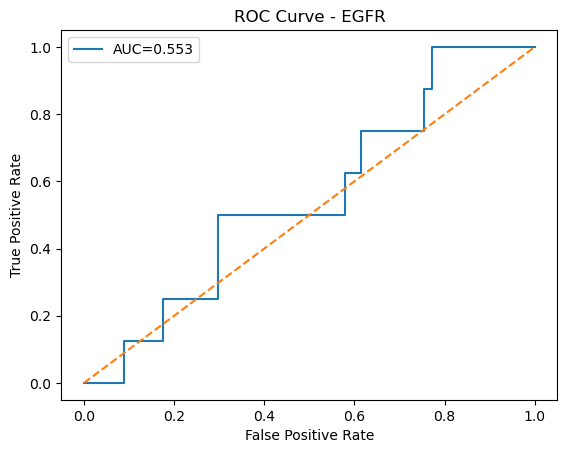

[TP53] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[TP53] n=216 | train pos/neg=92/59 | test pos/neg=40/25
  AUC=0.5550 | AUPRC=0.6916
  @0.50  Acc=0.5846 F1=0.6747 P=0.6512 R=0.7000
  thr* (F1)     = 0.0811 | details={'best_f1': 0.7540983606557378, 'precision': 0.6052631578947368, 'recall': 1.0}
  @thr*  Acc=0.6154 F1=0.7573 P=0.6190 R=0.9750


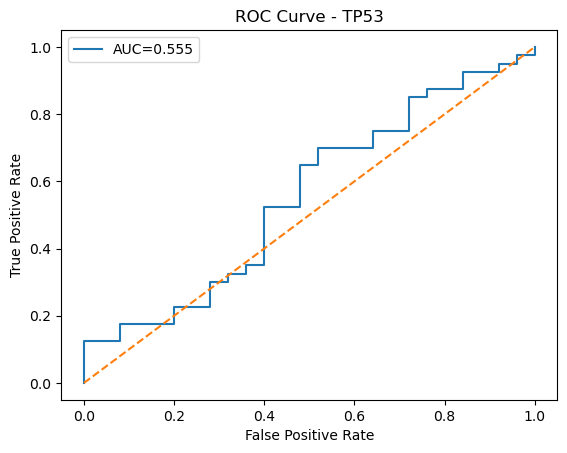

[KEAP1] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[KEAP1] n=216 | train pos/neg=25/126 | test pos/neg=11/54
  AUC=0.4832 | AUPRC=0.1687
  @0.50  Acc=0.7846 F1=0.0000 P=0.0000 R=0.0000
  thr* (F1)     = 0.5035 | details={'best_f1': 0.5882352941176471, 'precision': 0.45454545454545453, 'recall': 0.8333333333333334}
  @thr*  Acc=0.7846 F1=0.0000 P=0.0000 R=0.0000


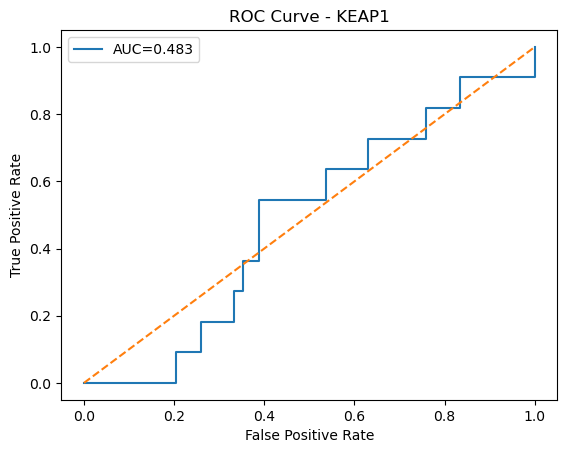

[NF1] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[NF1] n=216 | train pos/neg=19/132 | test pos/neg=8/57
  AUC=0.6776 | AUPRC=0.2023
  @0.50  Acc=0.8154 F1=0.2500 P=0.2500 R=0.2500
  thr* (F1)     = 0.2139 | details={'best_f1': 0.4615384615384615, 'precision': 0.375, 'recall': 0.6}
  @thr*  Acc=0.7077 F1=0.2400 P=0.1765 R=0.3750


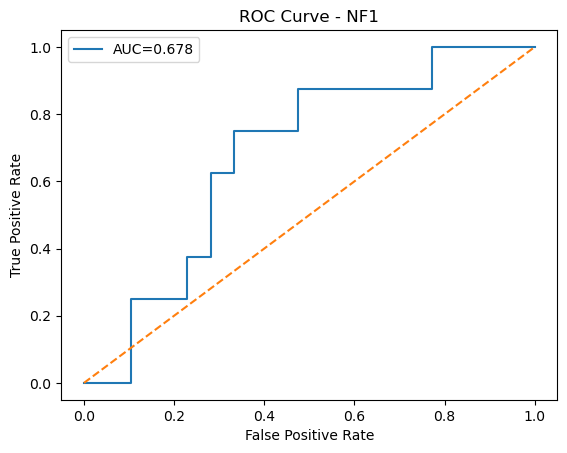

[STK11] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[STK11] n=216 | train pos/neg=13/138 | test pos/neg=5/60
  AUC=0.7767 | AUPRC=0.2110
  @0.50  Acc=0.8615 F1=0.0000 P=0.0000 R=0.0000
  thr* (F1)     = 0.7687 | details={'best_f1': 0.5, 'precision': 1.0, 'recall': 0.3333333333333333}
  @thr*  Acc=0.9077 F1=0.0000 P=0.0000 R=0.0000


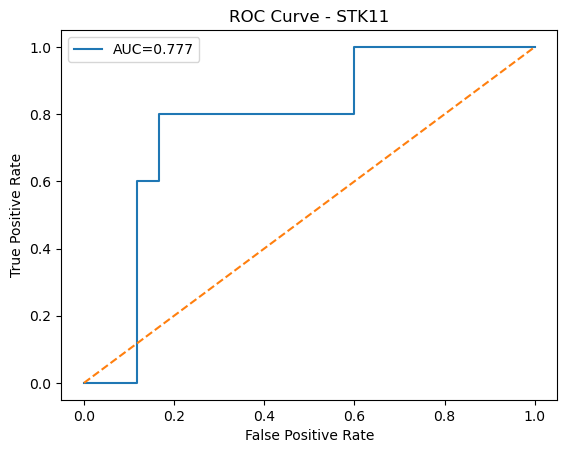

,gene,n,n_pos,n_neg,auc,auprc,acc_0.5,f1_0.5,p_0.5,r_0.5,thr_opt,acc_opt,f1_opt,p_opt,r_opt,thr_metric
0,EGFR,216,26,190,0.552632,0.155697,0.784615,0.125000,0.125000,0.125,0.015756,0.353846,0.222222,0.130435,0.750,f1
1,TP53,216,132,84,0.555000,0.691643,0.584615,0.674699,0.651163,0.700,0.081117,0.615385,0.757282,0.619048,0.975,f1
2,KEAP1,216,36,180,0.483165,0.168691,0.784615,0.000000,0.000000,0.000,0.503500,0.784615,0.000000,0.000000,0.000,f1
3,NF1,216,27,189,0.677632,0.202273,0.815385,0.250000,0.250000,0.250,0.213931,0.707692,0.240000,0.176471,0.375,f1
4,STK11,216,18,198,0.776667,0.210978,0.861538,0.000000,0.000000,0.000,0.768686,0.907692,0.000000,0.000000,0.000,f1


Saved: /home/rapids/notebooks/slima/mutation_xgb_metrics_with_thresholds_jan2026.csv


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve,
    average_precision_score,
)
import xgboost as xgb

# ----------------------------------------------------------
# Helper: find optimal threshold (maximize F1 by default)
# ----------------------------------------------------------
def find_best_threshold(y_true: np.ndarray, y_prob: np.ndarray, metric: str = "f1") -> tuple[float, dict]:
    """
    Find probability threshold that maximizes a metric on (y_true, y_prob).

    metric options:
      - "f1" (default): maximize F1
      - "youden": maximize (TPR - FPR) from ROC
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if metric == "youden":
        fpr, tpr, thr = roc_curve(y_true, y_prob)
        j = tpr - fpr
        idx = int(np.nanargmax(j))
        best_thr = float(thr[idx])
        details = {"youden_j": float(j[idx]), "tpr": float(tpr[idx]), "fpr": float(fpr[idx])}
        return best_thr, details

    # Default: F1 sweep via precision-recall thresholds
    precisions, recalls, thr = precision_recall_curve(y_true, y_prob)
    # precision_recall_curve returns thresholds of length N-1
    # Align by ignoring last precision/recall point (no threshold)
    f1s = 2 * precisions[:-1] * recalls[:-1] / np.clip(precisions[:-1] + recalls[:-1], 1e-12, None)
    idx = int(np.nanargmax(f1s))
    best_thr = float(thr[idx])
    details = {"best_f1": float(f1s[idx]), "precision": float(precisions[idx]), "recall": float(recalls[idx])}
    return best_thr, details

# ----------------------------------------------------------
# Entrenamiento y evaluación por gen con umbral optimizado
# ----------------------------------------------------------
def run_xgb_for_gene(df_gene: pd.DataFrame, gene: str, random_state: int = 42, thr_metric: str = "f1"):
    """
    - Split train/test (stratified)
    - Choose threshold on a validation split from train (NOT on test)
    - Refit on full train
    - Evaluate test using optimized threshold
    """
    X = df_gene[HISTO_COLS].values
    y = df_gene["y"].values.astype(int)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=random_state, stratify=y
    )

    # Internal validation split for threshold selection
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.25, random_state=random_state, stratify=y_train
    )

    # Class imbalance weight (computed on training fold only)
    n_pos_tr = int(y_tr.sum())
    n_neg_tr = int((y_tr == 0).sum())
    scale_pos_weight = (n_neg_tr / n_pos_tr) if n_pos_tr > 0 else 1.0

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        eval_metric="logloss",
    )

    model.fit(X_tr, y_tr)

    # Probabilities for threshold selection (VAL)
    y_val_prob = model.predict_proba(X_val)[:, 1]
    best_thr, thr_details = find_best_threshold(y_val, y_val_prob, metric=thr_metric)

    # Refit on full training set with same imbalance weight recomputed on full train
    n_pos_train = int(y_train.sum())
    n_neg_train = int((y_train == 0).sum())
    scale_pos_weight_full = (n_neg_train / n_pos_train) if n_pos_train > 0 else 1.0

    model_full = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        scale_pos_weight=scale_pos_weight_full,
        random_state=random_state,
        eval_metric="logloss",
    )
    model_full.fit(X_train, y_train)

    # TEST probabilities
    y_prob = model_full.predict_proba(X_test)[:, 1]

    # Metrics that are threshold-free
    auc = roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan
    auprc = average_precision_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else np.nan

    # Default 0.5 threshold
    y_pred_05 = (y_prob >= 0.5).astype(int)
    acc_05 = accuracy_score(y_test, y_pred_05)
    f1_05 = f1_score(y_test, y_pred_05, zero_division=0)
    p_05 = precision_score(y_test, y_pred_05, zero_division=0)
    r_05 = recall_score(y_test, y_pred_05, zero_division=0)

    # Optimized threshold
    y_pred_opt = (y_prob >= best_thr).astype(int)
    acc_opt = accuracy_score(y_test, y_pred_opt)
    f1_opt = f1_score(y_test, y_pred_opt, zero_division=0)
    p_opt = precision_score(y_test, y_pred_opt, zero_division=0)
    r_opt = recall_score(y_test, y_pred_opt, zero_division=0)

    # Report
    print(
        f"\n[{gene}] n={len(y)} | train pos/neg={n_pos_train}/{n_neg_train} | test pos/neg={int(y_test.sum())}/{int((y_test==0).sum())}"
    )
    print(f"  AUC={auc:.4f} | AUPRC={auprc:.4f}")
    print(f"  @0.50  Acc={acc_05:.4f} F1={f1_05:.4f} P={p_05:.4f} R={r_05:.4f}")
    if thr_metric == "youden":
        print(f"  thr* (Youden) = {best_thr:.4f} | details={thr_details}")
    else:
        print(f"  thr* (F1)     = {best_thr:.4f} | details={thr_details}")
    print(f"  @thr*  Acc={acc_opt:.4f} F1={f1_opt:.4f} P={p_opt:.4f} R={r_opt:.4f}")

    # ROC curve plot
    if len(np.unique(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {gene}")
        plt.legend()
        plt.show()

    return {
        "gene": gene,
        "n": int(len(y)),
        "n_pos": int(y.sum()),
        "n_neg": int((y == 0).sum()),
        "auc": float(auc) if auc == auc else np.nan,
        "auprc": float(auprc) if auprc == auprc else np.nan,
        # 0.5 threshold metrics
        "acc_0.5": float(acc_05),
        "f1_0.5": float(f1_05),
        "p_0.5": float(p_05),
        "r_0.5": float(r_05),
        # optimized threshold metrics
        "thr_opt": float(best_thr),
        "acc_opt": float(acc_opt),
        "f1_opt": float(f1_opt),
        "p_opt": float(p_opt),
        "r_opt": float(r_opt),
        "thr_metric": thr_metric,
    }

# ----------------------------------------------------------
# Run for target genes
# ----------------------------------------------------------
genes = ["EGFR", "TP53", "KEAP1", "NF1", "STK11"]

results = []
for gene in genes:
    df_gene = build_case_level_dataset_for_gene(df_all, df_histo, gene)
    res = run_xgb_for_gene(df_gene, gene, thr_metric="f1")  # change to "youden" if preferred
    results.append(res)

df_results = pd.DataFrame(results)

# Pretty print
display(df_results)

# Save metrics
out_csv = "/home/rapids/notebooks/slima/mutation_xgb_metrics_with_thresholds_jan2026.csv"
df_results.to_csv(out_csv, index=False)
print("Saved:", out_csv)

In [19]:

# -------------------------------------------------------------------
# Pipeline completo
# -------------------------------------------------------------------

def run_full_pipeline(maf_csv: str, out_dir: str):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"[INFO] Leyendo CSV MAF + histología desde: {maf_csv}")
    df_all, df_histo = read_maf_with_histology(maf_csv)

    # Guardar tabla histológica a nivel caso (por si la quieres usar en Excel)
    histo_out = out_dir / "histo_per_case_jan_2026.csv"
    df_histo.to_csv(histo_out, index=False)
    print(f"[INFO] Tabla histológica por caso -> {histo_out}")

    all_metrics = []
    for gene in MUT_GENES:
        print("\n" + "=" * 80)
        print(f"[INFO] Entrenando modelo para gen: {gene}")
        print("=" * 80)

        # m = run_xgb_for_gene(
        #     gene=gene,
        #     df_all=df_all,
        #     df_histo=df_histo,
        #     out_dir=out_dir,
        # )
        df_gene = build_case_level_dataset_for_gene(df_all, df_histo, gene)
        m = run_xgb_for_gene(df_gene, gene=gene)

        all_metrics.append(m)

    # Resumen de métricas de todos los genes
    metrics_df = pd.DataFrame(all_metrics)
    metrics_all_path = out_dir / "xgb_metrics_all_genes_december_2025_2.csv"
    metrics_df.to_csv(metrics_all_path, index=False)
    print(f"\n[OK] Resumen de métricas de todos los genes -> {metrics_all_path}")


# -------------------------------------------------------------------
# CLI amigable con notebooks
# -------------------------------------------------------------------

def cli():
    import argparse

    parser = argparse.ArgumentParser(
        description="XGBoost + SHAP para patrones histológicos vs mutaciones genéticas"
    )
    parser.add_argument(
        "--maf_csv",
        type=str,
        default="/home/rapids/notebooks/slima/MAF/cohortMAF.2025-12-17_with_histologic_patterns_dec2025.csv",
        help="Ruta al CSV combinado MAF + patrones histológicos (separado por ';').",
    )
    parser.add_argument(
        "--out_dir",
        type=str,
        default="/home/rapids/notebooks/slima/MAF/xgb_results",
        help="Directorio de salida para métricas, modelos y SHAP.",
    )

    # En notebooks, Jupyter mete argumentos extra (-f kernel.json). Los ignoramos.
    args, unknown = parser.parse_known_args()
    if unknown:
        print("[WARN] Ignorando argumentos desconocidos (probablemente de Jupyter):", unknown)

    run_full_pipeline(maf_csv=args.maf_csv, out_dir=args.out_dir)



[WARN] Ignorando argumentos desconocidos (probablemente de Jupyter): ['-f', '/home/rapids/.local/share/jupyter/runtime/kernel-eb8275ca-051b-4dd9-8211-348fcad83a86.json']
[INFO] Leyendo CSV MAF + histología desde: /home/rapids/notebooks/slima/MAF/cohortMAF.2025-12-17_with_histologic_patterns_dec2025.csv
[INFO] Tabla histológica por caso -> /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case_jan_2026.csv

[INFO] Entrenando modelo para gen: EGFR
[EGFR] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[EGFR] n=216 | train pos/neg=18/133 | test pos/neg=8/57
  AUC=0.5526 | AUPRC=0.1557
  @0.50  Acc=0.7846 F1=0.1250 P=0.1250 R=0.1250
  thr* (F1)     = 0.0158 | details={'best_f1': 0.33333333333333337, 'precision': 0.2, 'recall': 1.0}
  @thr*  Acc=0.3538 F1=0.2222 P=0.1304 R=0.7500


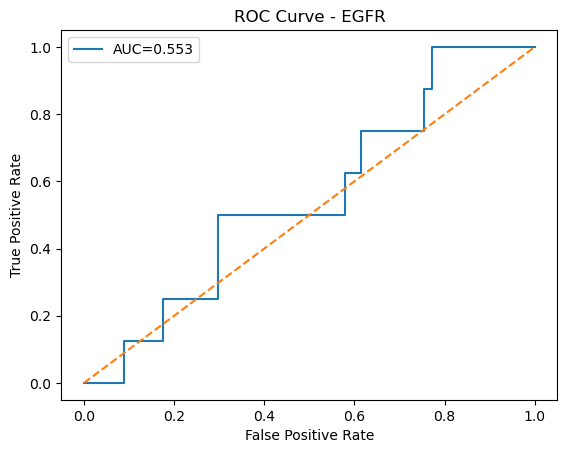


[INFO] Entrenando modelo para gen: TP53
[TP53] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[TP53] n=216 | train pos/neg=92/59 | test pos/neg=40/25
  AUC=0.5550 | AUPRC=0.6916
  @0.50  Acc=0.5846 F1=0.6747 P=0.6512 R=0.7000
  thr* (F1)     = 0.0811 | details={'best_f1': 0.7540983606557378, 'precision': 0.6052631578947368, 'recall': 1.0}
  @thr*  Acc=0.6154 F1=0.7573 P=0.6190 R=0.9750


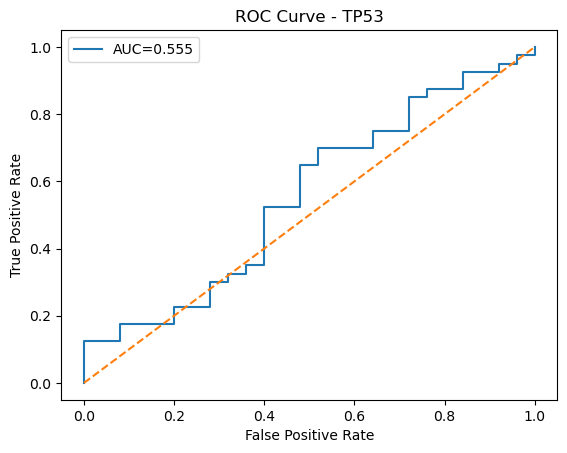


[INFO] Entrenando modelo para gen: KEAP1
[KEAP1] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[KEAP1] n=216 | train pos/neg=25/126 | test pos/neg=11/54
  AUC=0.4832 | AUPRC=0.1687
  @0.50  Acc=0.7846 F1=0.0000 P=0.0000 R=0.0000
  thr* (F1)     = 0.5035 | details={'best_f1': 0.5882352941176471, 'precision': 0.45454545454545453, 'recall': 0.8333333333333334}
  @thr*  Acc=0.7846 F1=0.0000 P=0.0000 R=0.0000


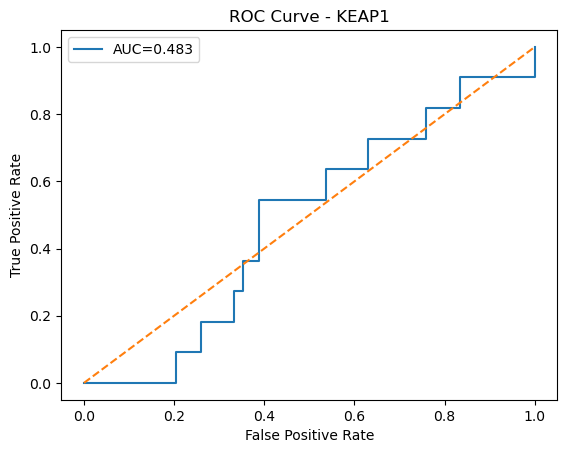


[INFO] Entrenando modelo para gen: NF1
[NF1] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[NF1] n=216 | train pos/neg=19/132 | test pos/neg=8/57
  AUC=0.6776 | AUPRC=0.2023
  @0.50  Acc=0.8154 F1=0.2500 P=0.2500 R=0.2500
  thr* (F1)     = 0.2139 | details={'best_f1': 0.4615384615384615, 'precision': 0.375, 'recall': 0.6}
  @thr*  Acc=0.7077 F1=0.2400 P=0.1765 R=0.3750


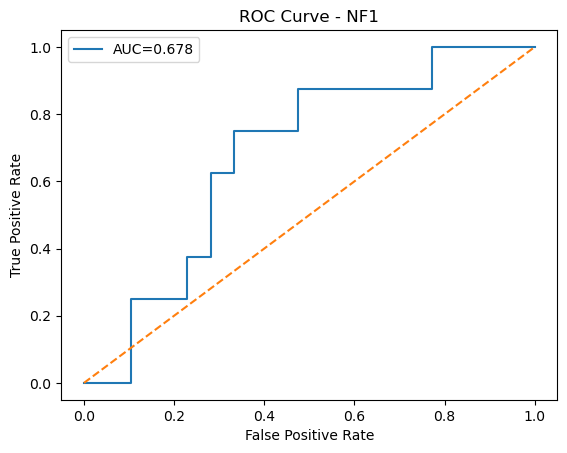


[INFO] Entrenando modelo para gen: STK11
[STK11] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[STK11] n=216 | train pos/neg=13/138 | test pos/neg=5/60
  AUC=0.7767 | AUPRC=0.2110
  @0.50  Acc=0.8615 F1=0.0000 P=0.0000 R=0.0000
  thr* (F1)     = 0.7687 | details={'best_f1': 0.5, 'precision': 1.0, 'recall': 0.3333333333333333}
  @thr*  Acc=0.9077 F1=0.0000 P=0.0000 R=0.0000


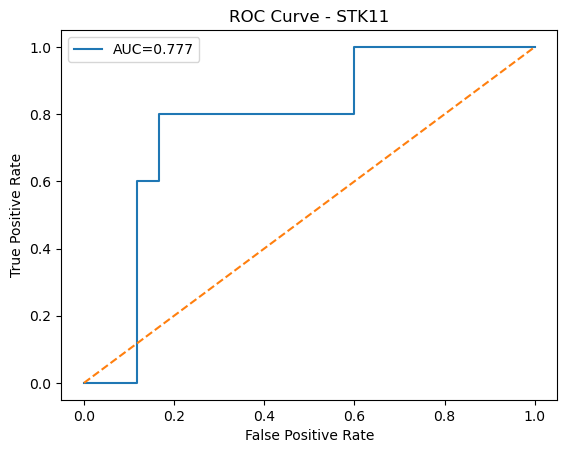


[INFO] Entrenando modelo para gen: CSMD3
[CSMD3] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[CSMD3] n=216 | train pos/neg=71/80 | test pos/neg=30/35
  AUC=0.4410 | AUPRC=0.4469
  @0.50  Acc=0.4154 F1=0.3214 P=0.3462 R=0.3000
  thr* (F1)     = 0.1898 | details={'best_f1': 0.72, 'precision': 0.5625, 'recall': 1.0}
  @thr*  Acc=0.4769 F1=0.5952 P=0.4630 R=0.8333


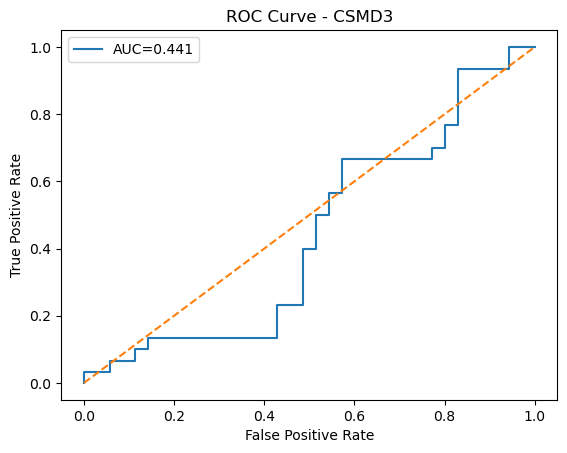


[INFO] Entrenando modelo para gen: LRP1B
[LRP1B] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[LRP1B] n=216 | train pos/neg=57/94 | test pos/neg=24/41
  AUC=0.4533 | AUPRC=0.3788
  @0.50  Acc=0.5231 F1=0.2791 P=0.3158 R=0.2500
  thr* (F1)     = 0.1203 | details={'best_f1': 0.6086956521739131, 'precision': 0.4375, 'recall': 1.0}
  @thr*  Acc=0.4000 F1=0.5063 P=0.3636 R=0.8333


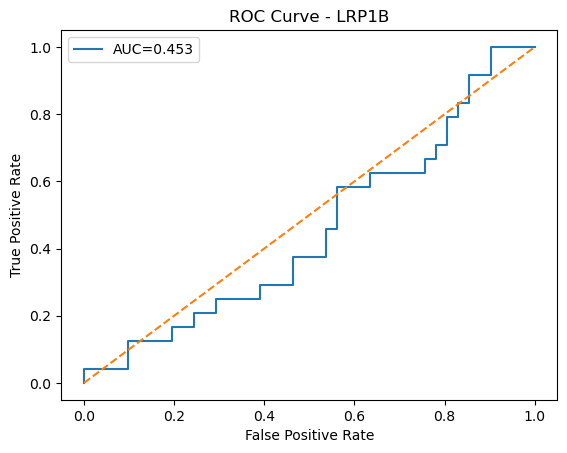


[INFO] Entrenando modelo para gen: MUC16
[MUC16] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[MUC16] n=216 | train pos/neg=72/79 | test pos/neg=31/34
  AUC=0.5313 | AUPRC=0.5280
  @0.50  Acc=0.4923 F1=0.4590 P=0.4667 R=0.4516
  thr* (F1)     = 0.2821 | details={'best_f1': 0.6976744186046512, 'precision': 0.6, 'recall': 0.8333333333333334}
  @thr*  Acc=0.5231 F1=0.5753 P=0.5000 R=0.6774


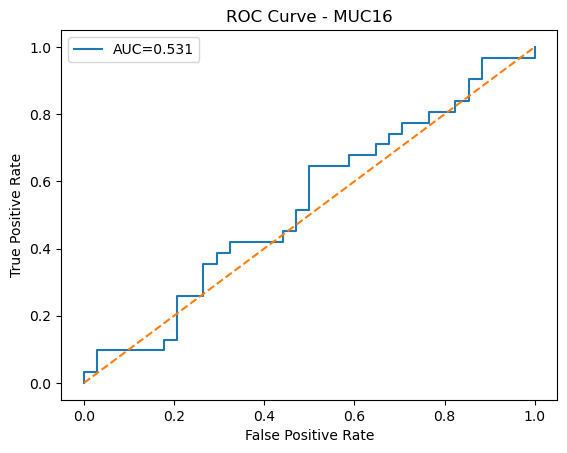


[INFO] Entrenando modelo para gen: RYR2
[RYR2] Casos totales en histo_per_case: 752 -> 216 tras filtrar casos sin patrones histológicos (todo cero).

[RYR2] n=216 | train pos/neg=70/81 | test pos/neg=30/35
  AUC=0.4324 | AUPRC=0.4621
  @0.50  Acc=0.4462 F1=0.3333 P=0.3750 R=0.3000
  thr* (F1)     = 0.0279 | details={'best_f1': 0.6428571428571429, 'precision': 0.47368421052631576, 'recall': 1.0}
  @thr*  Acc=0.4615 F1=0.6316 P=0.4615 R=1.0000


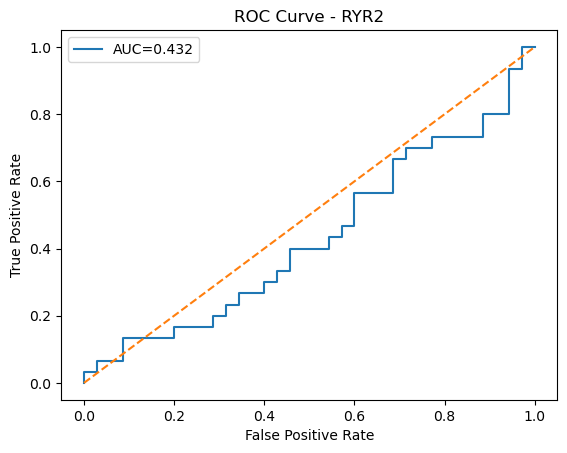


[OK] Resumen de métricas de todos los genes -> /home/rapids/notebooks/slima/MAF/xgb_results/xgb_metrics_all_genes_december_2025_2.csv


In [20]:

# Si ejecutas esta celda tal cual en el notebook, llama directamente al pipeline
if __name__ == "__main__":
    cli()


In [21]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


In [22]:

# -------------------------------------------------------------------
# Configuración básica
# -------------------------------------------------------------------
RESULTS_DIR = Path("/home/rapids/notebooks/slima/MAF/xgb_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

GENES = MUT_GENES

print(f"[INFO] Directorio de resultados: {RESULTS_DIR}")


[INFO] Directorio de resultados: /home/rapids/notebooks/slima/MAF/xgb_results


[INFO] Métricas leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_metrics_all_genes_december_2025_2.csv


,gene,n,n_pos,n_neg,auc,auprc,acc_0.5,f1_0.5,p_0.5,r_0.5,thr_opt,acc_opt,f1_opt,p_opt,r_opt,thr_metric
0,EGFR,216,26,190,0.552632,0.155697,0.784615,0.125000,0.125000,0.125,0.015756,0.353846,0.222222,0.130435,0.750,f1
1,TP53,216,132,84,0.555000,0.691643,0.584615,0.674699,0.651163,0.700,0.081117,0.615385,0.757282,0.619048,0.975,f1
2,KEAP1,216,36,180,0.483165,0.168691,0.784615,0.000000,0.000000,0.000,0.503500,0.784615,0.000000,0.000000,0.000,f1
3,NF1,216,27,189,0.677632,0.202273,0.815385,0.250000,0.250000,0.250,0.213931,0.707692,0.240000,0.176471,0.375,f1
4,STK11,216,18,198,0.776667,0.210978,0.861538,0.000000,0.000000,0.000,0.768686,0.907692,0.000000,0.000000,0.000,f1


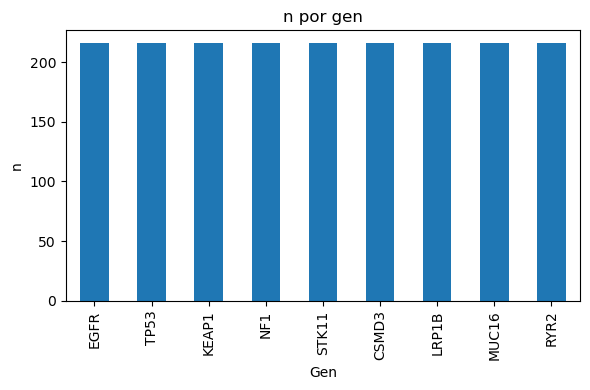

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_n.png


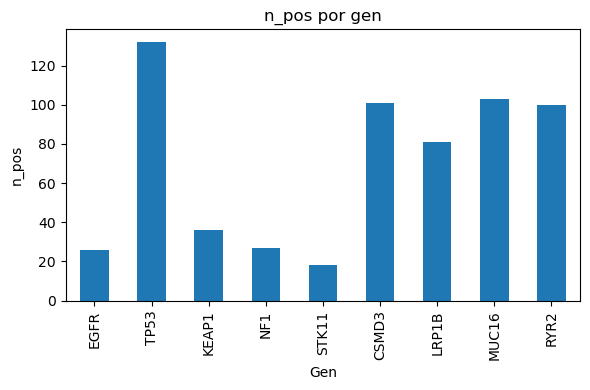

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_n_pos.png


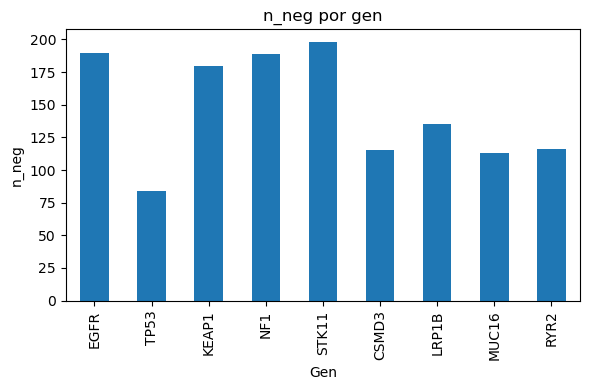

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_n_neg.png


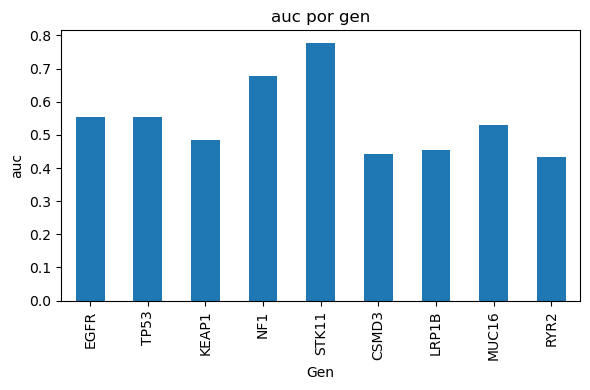

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_auc.png


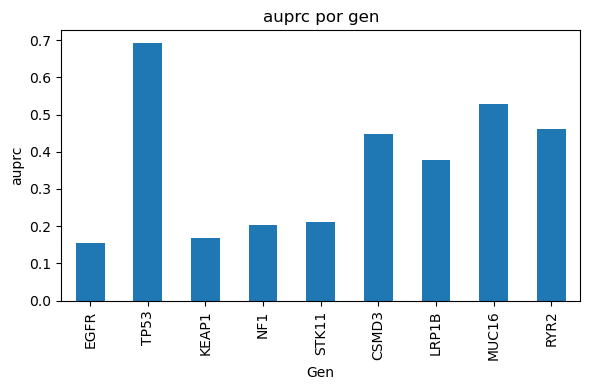

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_auprc.png


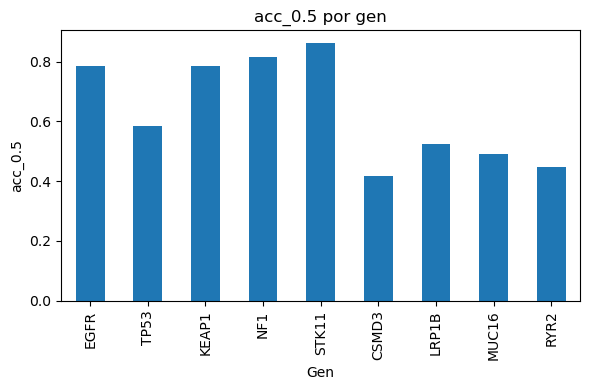

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_acc_0.5.png


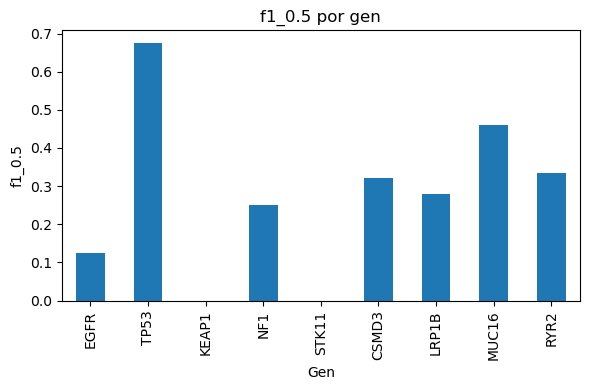

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_f1_0.5.png


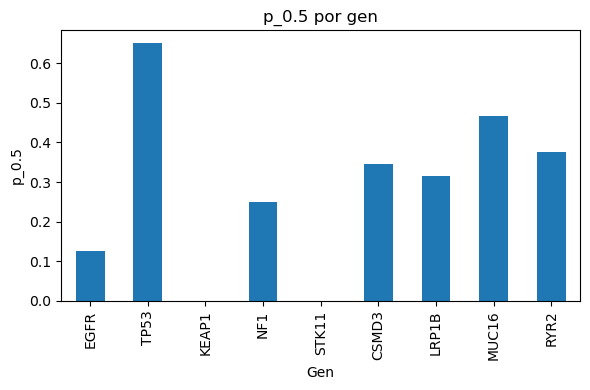

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_p_0.5.png


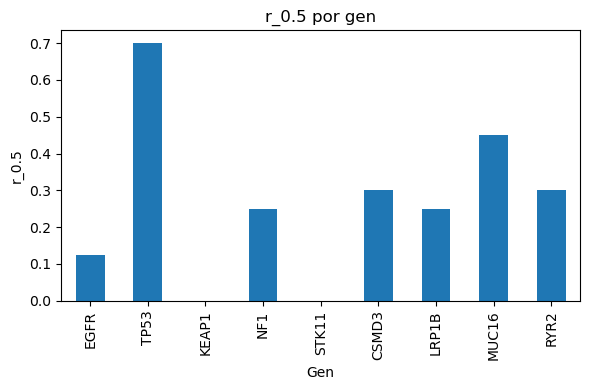

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_r_0.5.png


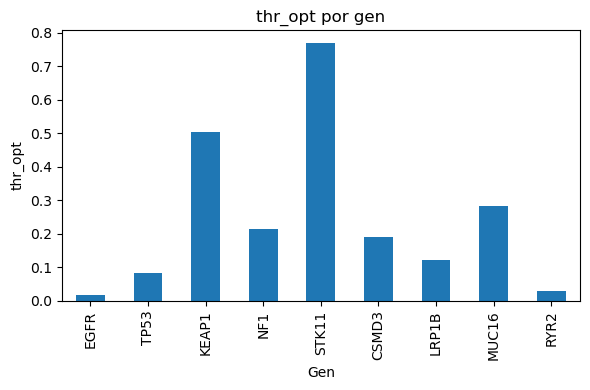

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_thr_opt.png


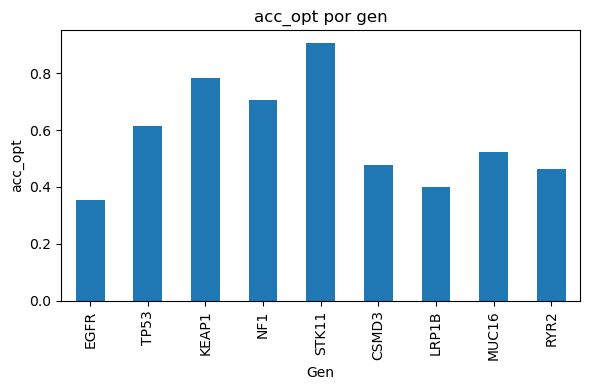

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_acc_opt.png


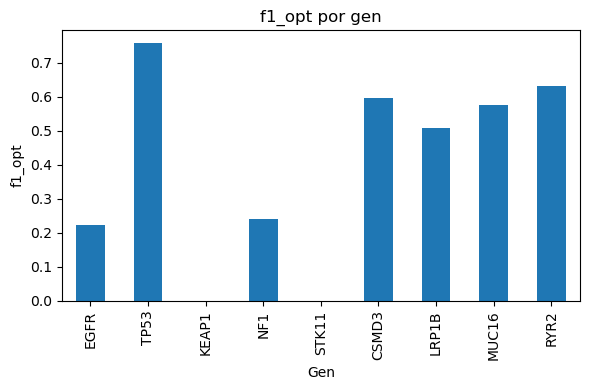

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_f1_opt.png


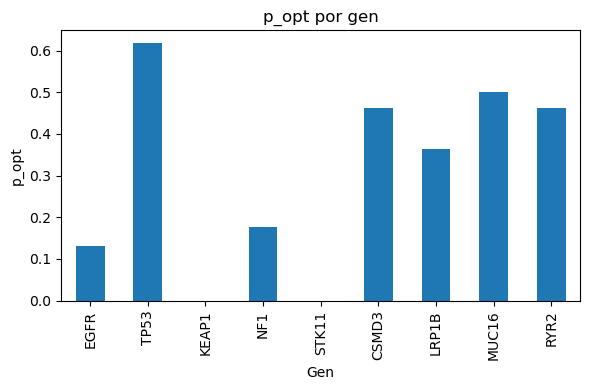

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_p_opt.png


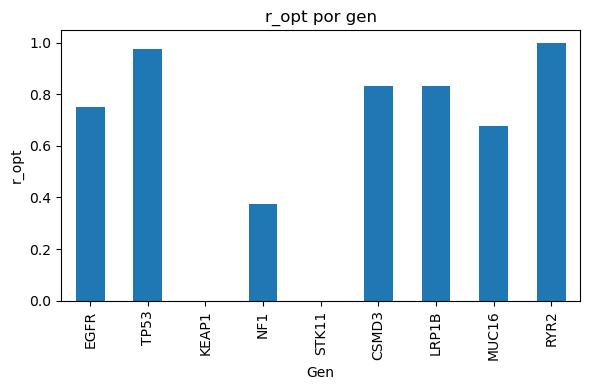

[OK] Guardada figura de métricas: /home/rapids/notebooks/slima/MAF/xgb_results/metrics_r_opt.png


In [23]:

# -------------------------------------------------------------------
# 1) Visualizar métricas globales por gen (xgb_metrics_all_genes.csv)
# -------------------------------------------------------------------
metrics_path = RESULTS_DIR / "xgb_metrics_all_genes_december_2025_2.csv"
if metrics_path.exists():
    df_metrics = pd.read_csv(metrics_path)
    print("[INFO] Métricas leídas de:", metrics_path)
    display(df_metrics.head())

    # Detectar columnas numéricas de métricas (ej. roc_auc, accuracy, f1, etc.)
    metric_cols = [
        c for c in df_metrics.columns
        if c not in ["gene"] and pd.api.types.is_numeric_dtype(df_metrics[c])
    ]

    for mc in metric_cols:
        plt.figure(figsize=(6, 4))
        subset = df_metrics.set_index("gene")[mc]
        subset.plot(kind="bar")
        plt.title(f"{mc} por gen")
        plt.ylabel(mc)
        plt.xlabel("Gen")
        plt.tight_layout()

        out_png = RESULTS_DIR / f"metrics_{mc}.png"
        plt.savefig(out_png, dpi=150)
        plt.show()
        print(f"[OK] Guardada figura de métricas: {out_png}")
else:
    print("[WARN] No se encontró xgb_metrics_all_genes.csv en", RESULTS_DIR)



[INFO] Gráfica de importancias para gen: EGFR
[INFO] Importancias de EGFR leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_EGFR.csv


,feature,importance
0,pct_acinar,0.175266
1,n_tiles_total,0.174892
2,pct_micropapillary,0.139666
3,pct_papillary,0.138341
4,pct_solid,0.132184


[INFO] Usando columna de importancia 'importance' para EGFR


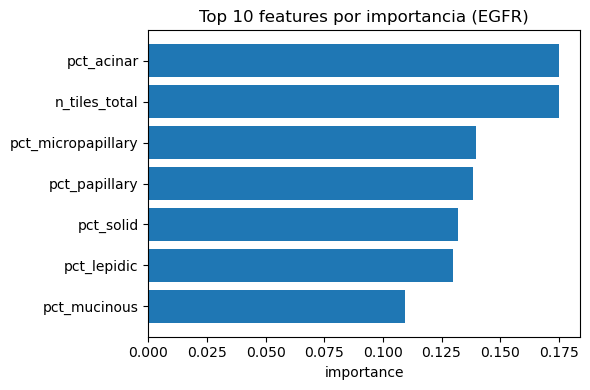

[OK] Guardada figura de importancias de features para EGFR: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_EGFR.png

[INFO] Gráfica de importancias para gen: TP53
[INFO] Importancias de TP53 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_TP53.csv


,feature,importance
0,pct_solid,0.161653
1,pct_lepidic,0.156800
2,pct_acinar,0.155171
3,pct_mucinous,0.138250
4,pct_papillary,0.136100


[INFO] Usando columna de importancia 'importance' para TP53


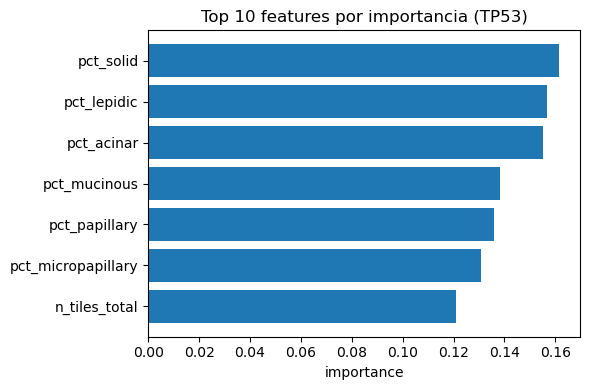

[OK] Guardada figura de importancias de features para TP53: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_TP53.png

[INFO] Gráfica de importancias para gen: KEAP1
[INFO] Importancias de KEAP1 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_KEAP1.csv


,feature,importance
0,pct_solid,0.194027
1,pct_micropapillary,0.180301
2,pct_lepidic,0.156004
3,pct_mucinous,0.135503
4,n_tiles_total,0.131394


[INFO] Usando columna de importancia 'importance' para KEAP1


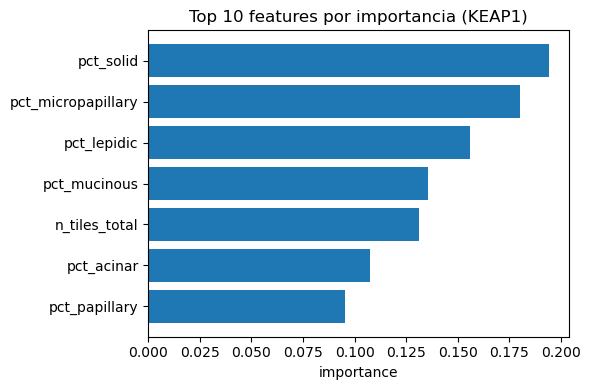

[OK] Guardada figura de importancias de features para KEAP1: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_KEAP1.png

[INFO] Gráfica de importancias para gen: NF1
[INFO] Importancias de NF1 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_NF1.csv


,feature,importance
0,pct_micropapillary,0.235468
1,pct_mucinous,0.178815
2,n_tiles_total,0.142110
3,pct_lepidic,0.122181
4,pct_solid,0.116149


[INFO] Usando columna de importancia 'importance' para NF1


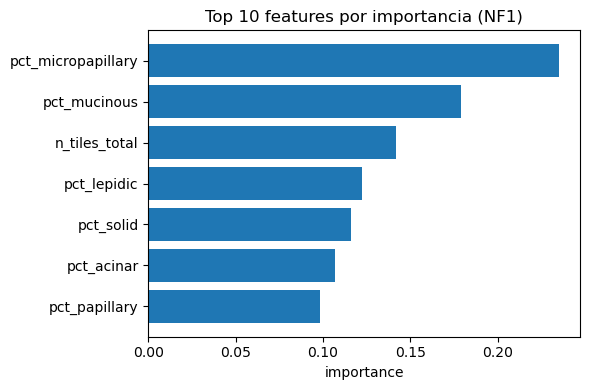

[OK] Guardada figura de importancias de features para NF1: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_NF1.png

[INFO] Gráfica de importancias para gen: STK11
[INFO] Importancias de STK11 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_STK11.csv


,feature,importance
0,n_tiles_total,0.219012
1,pct_papillary,0.174988
2,pct_mucinous,0.152441
3,pct_solid,0.145240
4,pct_micropapillary,0.127662


[INFO] Usando columna de importancia 'importance' para STK11


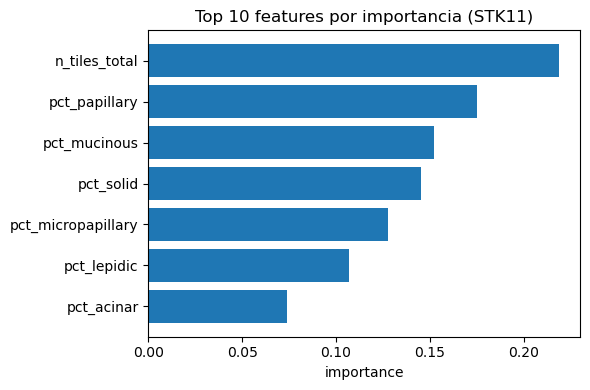

[OK] Guardada figura de importancias de features para STK11: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_STK11.png

[INFO] Gráfica de importancias para gen: CSMD3
[INFO] Importancias de CSMD3 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_CSMD3.csv


,feature,importance
0,n_tiles_total,0.162330
1,pct_micropapillary,0.161361
2,pct_mucinous,0.144337
3,pct_papillary,0.142920
4,pct_solid,0.137654


[INFO] Usando columna de importancia 'importance' para CSMD3


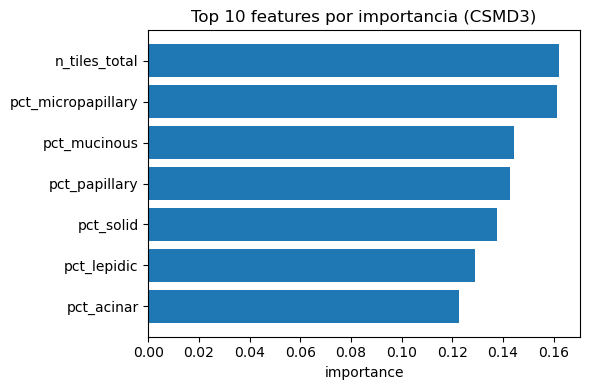

[OK] Guardada figura de importancias de features para CSMD3: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_CSMD3.png

[INFO] Gráfica de importancias para gen: LRP1B
[INFO] Importancias de LRP1B leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_LRP1B.csv


,feature,importance
0,n_tiles_total,0.155825
1,pct_acinar,0.150294
2,pct_micropapillary,0.146927
3,pct_mucinous,0.144809
4,pct_lepidic,0.140392


[INFO] Usando columna de importancia 'importance' para LRP1B


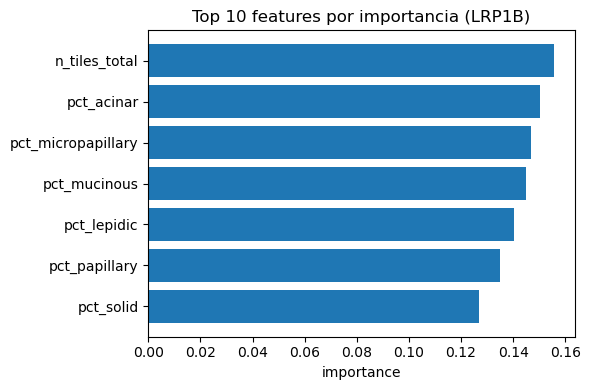

[OK] Guardada figura de importancias de features para LRP1B: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_LRP1B.png

[INFO] Gráfica de importancias para gen: MUC16
[INFO] Importancias de MUC16 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_MUC16.csv


,feature,importance
0,n_tiles_total,0.164449
1,pct_lepidic,0.157610
2,pct_mucinous,0.153884
3,pct_solid,0.136799
4,pct_papillary,0.131880


[INFO] Usando columna de importancia 'importance' para MUC16


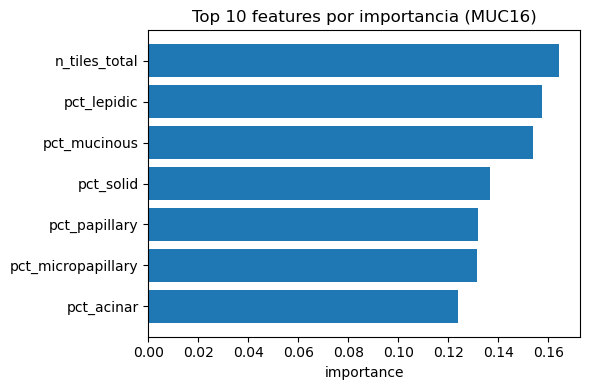

[OK] Guardada figura de importancias de features para MUC16: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_MUC16.png

[INFO] Gráfica de importancias para gen: RYR2
[INFO] Importancias de RYR2 leídas de: /home/rapids/notebooks/slima/MAF/xgb_results/xgb_importances_RYR2.csv


,feature,importance
0,pct_solid,0.154467
1,pct_acinar,0.152998
2,n_tiles_total,0.152759
3,pct_micropapillary,0.139349
4,pct_papillary,0.137169


[INFO] Usando columna de importancia 'importance' para RYR2


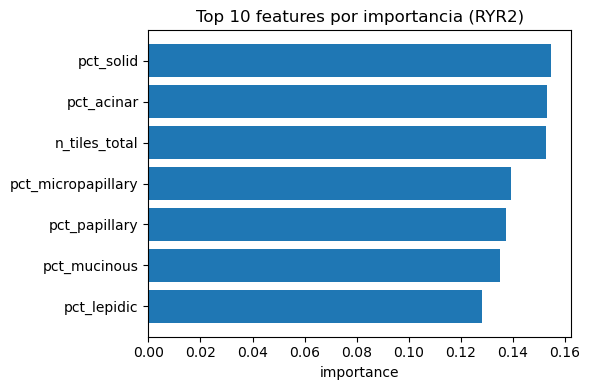

[OK] Guardada figura de importancias de features para RYR2: /home/rapids/notebooks/slima/MAF/xgb_results/feature_importances_RYR2.png


In [24]:

# -------------------------------------------------------------------
# 2) Visualizar importancias de features por gen (xgb_importances_*.csv)
# -------------------------------------------------------------------
def plot_feature_importances_for_gene(gene: str, top_n: int = 10):
    imp_path = RESULTS_DIR / f"xgb_importances_{gene}.csv"
    if not imp_path.exists():
        print(f"[WARN] No se encontró importances para {gene} -> {imp_path}")
        return

    df_imp = pd.read_csv(imp_path)
    print(f"[INFO] Importancias de {gene} leídas de:", imp_path)
    display(df_imp.head())

    # Intentar detectar columna de importancia numérica
    # Nos quedamos con columnas numéricas excepto el índice/feature
    numeric_cols = [
        c for c in df_imp.columns
        if c not in ["feature", "feat", "name"] and pd.api.types.is_numeric_dtype(df_imp[c])
    ]
    if not numeric_cols:
        print(f"[WARN] No se encontraron columnas numéricas de importancia para {gene}")
        return

    # Tomar la primera métrica numérica como principal
    imp_col = numeric_cols[0]
    print(f"[INFO] Usando columna de importancia '{imp_col}' para {gene}")

    # Determinar la columna con el nombre de la feature
    if "feature" in df_imp.columns:
        feat_col = "feature"
    elif "feat" in df_imp.columns:
        feat_col = "feat"
    elif "name" in df_imp.columns:
        feat_col = "name"
    else:
        # Si no hay nombre claro, usar la primera columna no numérica
        non_numeric = [c for c in df_imp.columns if c not in numeric_cols]
        if not non_numeric:
            print(f"[WARN] No hay columna obvia de 'feature' para {gene}")
            return
        feat_col = non_numeric[0]

    df_imp_sorted = df_imp.sort_values(by=imp_col, ascending=False).head(top_n)

    plt.figure(figsize=(6, 4))
    plt.barh(df_imp_sorted[feat_col], df_imp_sorted[imp_col])
    plt.gca().invert_yaxis()
    plt.xlabel(imp_col)
    plt.title(f"Top {top_n} features por importancia ({gene})")
    plt.tight_layout()

    out_png = RESULTS_DIR / f"feature_importances_{gene}.png"
    plt.savefig(out_png, dpi=150)
    plt.show()
    print(f"[OK] Guardada figura de importancias de features para {gene}: {out_png}")

for g in GENES:
    print("\n" + "=" * 70)
    print(f"[INFO] Gráfica de importancias para gen: {g}")
    print("=" * 70)
    plot_feature_importances_for_gene(g)



In [25]:
# -------------------------------------------------------------------
# 3) Visualizar resumen SHAP por gen (shap_summary_*.csv)
# -------------------------------------------------------------------
def plot_shap_summary_for_gene(gene: str, top_n: int = 10):
    shap_path = RESULTS_DIR / f"shap_summary_{gene}.csv"
    if not shap_path.exists():
        print(f"[WARN] No se encontró shap_summary para {gene} -> {shap_path}")
        return

    df_shap = pd.read_csv(shap_path)
    print(f"[INFO] SHAP summary de {gene} leído de:", shap_path)
    display(df_shap.head())

    # Buscar columnas numéricas (ej. mean_abs_shap, mean_shap, etc.)
    numeric_cols = [
        c for c in df_shap.columns
        if c not in ["feature", "feat", "name"] and pd.api.types.is_numeric_dtype(df_shap[c])
    ]
    if not numeric_cols:
        print(f"[WARN] No se encontraron columnas numéricas de SHAP para {gene}")
        return

    shap_col = numeric_cols[0]
    print(f"[INFO] Usando columna SHAP '{shap_col}' para {gene}")

    # Columna de nombre de feature
    if "feature" in df_shap.columns:
        feat_col = "feature"
    elif "feat" in df_shap.columns:
        feat_col = "feat"
    elif "name" in df_shap.columns:
        feat_col = "name"
    else:
        non_numeric = [c for c in df_shap.columns if c not in numeric_cols]
        if not non_numeric:
            print(f"[WARN] No hay columna obvia de 'feature' en SHAP para {gene}")
            return
        feat_col = non_numeric[0]

    df_shap_sorted = df_shap.sort_values(by=shap_col, ascending=False).head(top_n)

    plt.figure(figsize=(6, 4))
    plt.barh(df_shap_sorted[feat_col], df_shap_sorted[shap_col])
    plt.gca().invert_yaxis()
    plt.xlabel(shap_col)
    plt.title(f"Top {top_n} features por |SHAP| medio ({gene})")
    plt.tight_layout()

    out_png = RESULTS_DIR / f"shap_summary_{gene}.png"
    plt.savefig(out_png, dpi=150)
    plt.show()
    print(f"[OK] Guardada figura SHAP para {gene}: {out_png}")



[INFO] Gráfica SHAP summary para gen: EGFR
[INFO] SHAP summary de EGFR leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_EGFR.csv


,feature,mean_abs_shap
0,n_tiles_total,1.228973
1,pct_papillary,1.048107
2,pct_lepidic,0.785762
3,pct_acinar,0.745431
4,pct_micropapillary,0.711723


[INFO] Usando columna SHAP 'mean_abs_shap' para EGFR


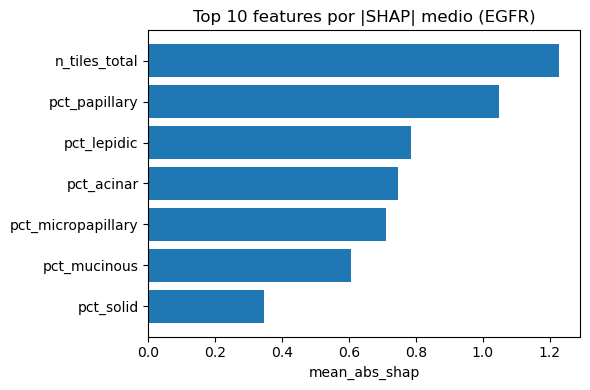

[OK] Guardada figura SHAP para EGFR: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_EGFR.png

[INFO] Gráfica SHAP summary para gen: TP53
[INFO] SHAP summary de TP53 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_TP53.csv


,feature,mean_abs_shap
0,pct_lepidic,0.544600
1,pct_solid,0.482515
2,pct_papillary,0.440628
3,pct_mucinous,0.394605
4,pct_acinar,0.372505


[INFO] Usando columna SHAP 'mean_abs_shap' para TP53


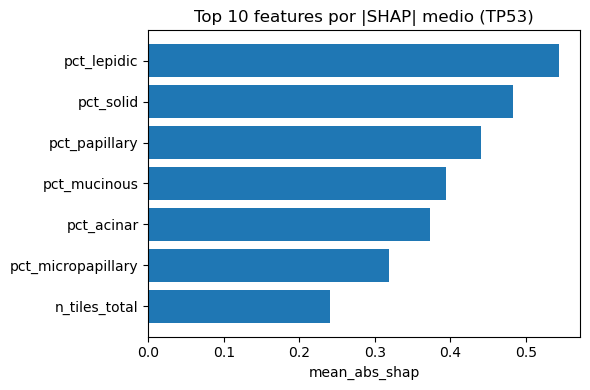

[OK] Guardada figura SHAP para TP53: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_TP53.png

[INFO] Gráfica SHAP summary para gen: KEAP1
[INFO] SHAP summary de KEAP1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_KEAP1.csv


,feature,mean_abs_shap
0,pct_micropapillary,0.827705
1,pct_solid,0.802956
2,pct_lepidic,0.754411
3,n_tiles_total,0.643707
4,pct_acinar,0.628259


[INFO] Usando columna SHAP 'mean_abs_shap' para KEAP1


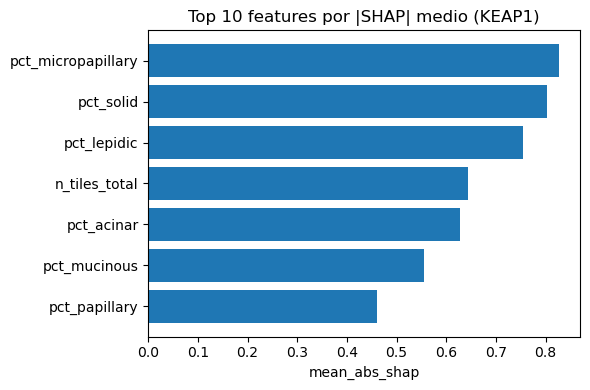

[OK] Guardada figura SHAP para KEAP1: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_KEAP1.png

[INFO] Gráfica SHAP summary para gen: NF1
[INFO] SHAP summary de NF1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_NF1.csv


,feature,mean_abs_shap
0,pct_micropapillary,1.474081
1,pct_lepidic,1.010000
2,pct_mucinous,0.978190
3,n_tiles_total,0.890204
4,pct_solid,0.661763


[INFO] Usando columna SHAP 'mean_abs_shap' para NF1


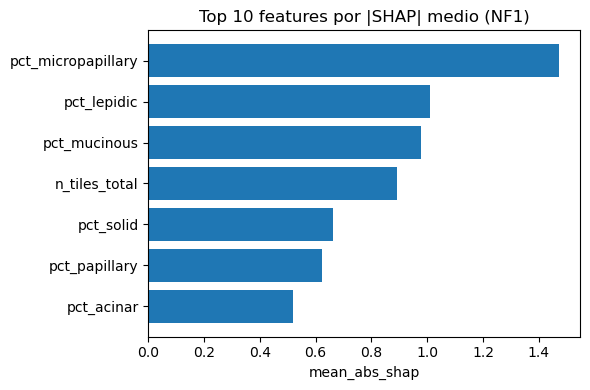

[OK] Guardada figura SHAP para NF1: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_NF1.png

[INFO] Gráfica SHAP summary para gen: STK11
[INFO] SHAP summary de STK11 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_STK11.csv


,feature,mean_abs_shap
0,pct_papillary,1.689100
1,pct_solid,1.450528
2,n_tiles_total,1.278518
3,pct_lepidic,0.996877
4,pct_micropapillary,0.888120


[INFO] Usando columna SHAP 'mean_abs_shap' para STK11


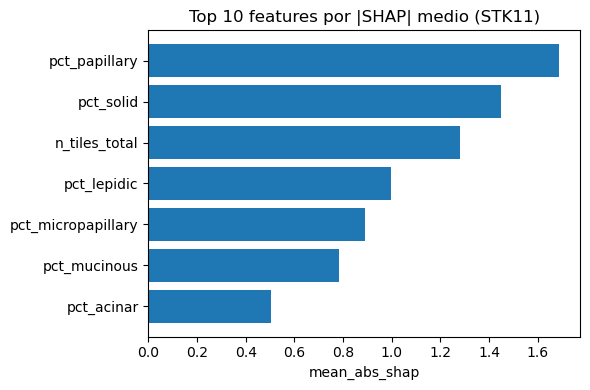

[OK] Guardada figura SHAP para STK11: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_STK11.png

[INFO] Gráfica SHAP summary para gen: CSMD3
[INFO] SHAP summary de CSMD3 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_CSMD3.csv


,feature,mean_abs_shap
0,n_tiles_total,0.628024
1,pct_micropapillary,0.549540
2,pct_papillary,0.467877
3,pct_lepidic,0.425303
4,pct_mucinous,0.392655


[INFO] Usando columna SHAP 'mean_abs_shap' para CSMD3


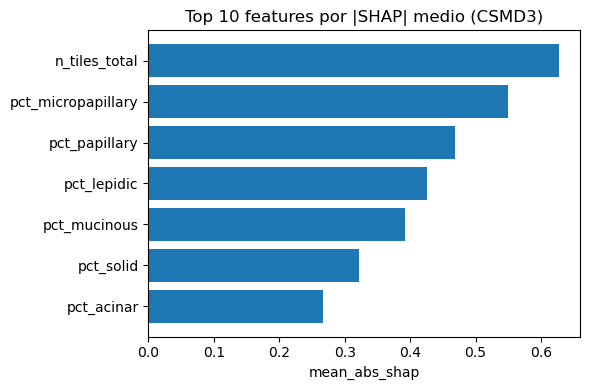

[OK] Guardada figura SHAP para CSMD3: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_CSMD3.png

[INFO] Gráfica SHAP summary para gen: LRP1B
[INFO] SHAP summary de LRP1B leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_LRP1B.csv


,feature,mean_abs_shap
0,n_tiles_total,0.688420
1,pct_acinar,0.633731
2,pct_mucinous,0.390516
3,pct_micropapillary,0.386363
4,pct_lepidic,0.363944


[INFO] Usando columna SHAP 'mean_abs_shap' para LRP1B


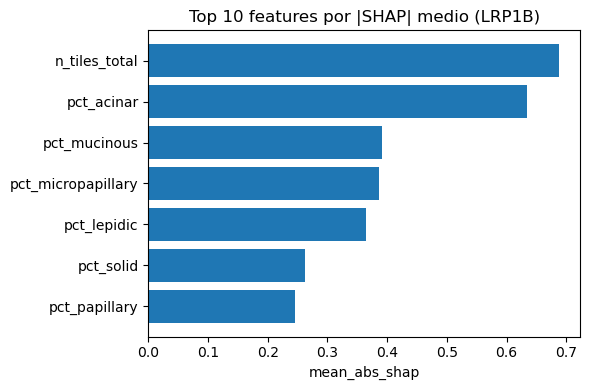

[OK] Guardada figura SHAP para LRP1B: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_LRP1B.png

[INFO] Gráfica SHAP summary para gen: MUC16
[INFO] SHAP summary de MUC16 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_MUC16.csv


,feature,mean_abs_shap
0,pct_mucinous,0.512372
1,pct_micropapillary,0.504323
2,pct_lepidic,0.487711
3,n_tiles_total,0.472295
4,pct_papillary,0.442698


[INFO] Usando columna SHAP 'mean_abs_shap' para MUC16


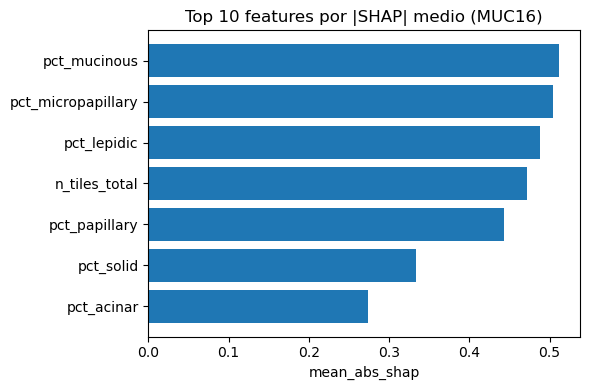

[OK] Guardada figura SHAP para MUC16: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_MUC16.png

[INFO] Gráfica SHAP summary para gen: RYR2
[INFO] SHAP summary de RYR2 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_RYR2.csv


,feature,mean_abs_shap
0,pct_acinar,0.464805
1,n_tiles_total,0.443792
2,pct_lepidic,0.442577
3,pct_mucinous,0.434436
4,pct_micropapillary,0.403219


[INFO] Usando columna SHAP 'mean_abs_shap' para RYR2


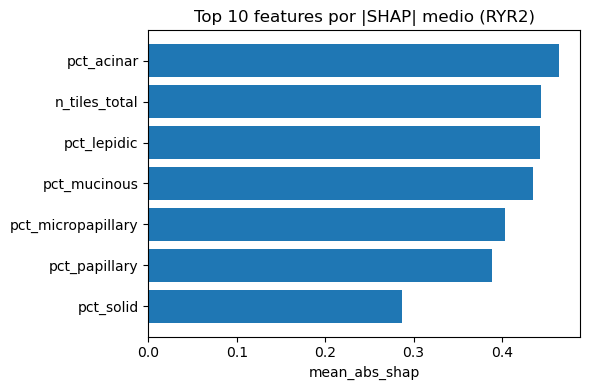

[OK] Guardada figura SHAP para RYR2: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_RYR2.png

[OK] Todas las figuras han sido generadas y guardadas en: /home/rapids/notebooks/slima/MAF/xgb_results


In [26]:

for g in GENES:
    print("\n" + "=" * 70)
    print(f"[INFO] Gráfica SHAP summary para gen: {g}")
    print("=" * 70)
    plot_shap_summary_for_gene(g)

print("\n[OK] Todas las figuras han sido generadas y guardadas en:", RESULTS_DIR)


In [27]:
HISTO_FEATURES = [
    "n_tiles_total",
    "pct_acinar",
    "pct_lepidic",
    "pct_micropapillary",
    "pct_mucinous",
    "pct_papillary",
    "pct_solid",
]


In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import shap
from pathlib import Path

# RESULTS_DIR ya debería estar definido arriba:
# RESULTS_DIR = Path("/home/rapids/notebooks/slima/MAF/xgb_results")

def plot_shap_summary_for_gene(gene: str, top_n: int = 10):
    """
    - Sigue leyendo shap_summary_{gene}.csv y dibuja el bar chart (como antes).
    - Además:
        * Carga shap_values_{gene}.csv + histo_per_case.csv
        * Genera un SHAP summary real (beeswarm)
        * Genera un SHAP force plot para un caso TCGA (idealmente mutado en ese gen)
    """

    # ------------------------------------------------------------------
    # 1) Lo que YA HACÍAS: leer shap_summary_{gene}.csv y bar chart
    # ------------------------------------------------------------------
    shap_path = RESULTS_DIR / f"shap_summary_{gene}.csv"
    if not shap_path.exists():
        print(f"[WARN] No se encontró shap_summary para {gene} -> {shap_path}")
    else:
        df_shap = pd.read_csv(shap_path)
        print(f"[INFO] SHAP summary de {gene} leído de:", shap_path)
        display(df_shap.head())

        # Buscar columnas numéricas (ej. mean_abs_shap, mean_shap, etc.)
        numeric_cols = [
            c for c in df_shap.columns
            if c not in ["feature", "feat", "name"] and pd.api.types.is_numeric_dtype(df_shap[c])
        ]
        if not numeric_cols:
            print(f"[WARN] No se encontraron columnas numéricas de SHAP para {gene}")
        else:
            shap_col = numeric_cols[0]
            print(f"[INFO] Usando columna SHAP '{shap_col}' para {gene}")

            # Columna de nombre de feature
            if "feature" in df_shap.columns:
                feat_col = "feature"
            elif "feat" in df_shap.columns:
                feat_col = "feat"
            elif "name" in df_shap.columns:
                feat_col = "name"
            else:
                non_numeric = [c for c in df_shap.columns if c not in numeric_cols]
                if not non_numeric:
                    print(f"[WARN] No hay columna obvia de 'feature' en SHAP para {gene}")
                    feat_col = None
                else:
                    feat_col = non_numeric[0]

            if feat_col is not None:
                df_shap_sorted = df_shap.sort_values(by=shap_col, ascending=False).head(top_n)

                plt.figure(figsize=(6, 4))
                plt.barh(df_shap_sorted[feat_col], df_shap_sorted[shap_col])
                plt.gca().invert_yaxis()
                plt.xlabel(shap_col)
                plt.title(f"Top {top_n} features por |SHAP| medio ({gene})")
                plt.tight_layout()

                out_png = RESULTS_DIR / f"shap_summary_bar_{gene}.png"
                plt.savefig(out_png, dpi=150)
                plt.show()
                print(f"[OK] Guardada figura BAR SHAP para {gene}: {out_png}")

    # ------------------------------------------------------------------
    # 2) NUEVO: SHAP REAL (beeswarm global + force plot individual)
    # ------------------------------------------------------------------
    # a) Cargar shap_values_{gene}.csv
    shap_values_path = RESULTS_DIR / f"shap_values_{gene}.csv"
    if not shap_values_path.exists():
        print(f"[WARN] No se encontró shap_values para {gene} -> {shap_values_path}")
        return

    df_sv = pd.read_csv(shap_values_path)
    print(f"[INFO] SHAP values de {gene} leído de:", shap_values_path)

    # Identificar columna de caso (asumimos 'case_barcode', que es lo que usamos en el pipeline)
    case_col_sv = None
    for cand in ["case_barcode", "case_id", "Tumor_Sample_Barcode"]:
        if cand in df_sv.columns:
            case_col_sv = cand
            break
    if case_col_sv is None:
        # fallback: primera columna no numérica
        non_num = [c for c in df_sv.columns if not pd.api.types.is_numeric_dtype(df_sv[c])]
        case_col_sv = non_num[0] if non_num else df_sv.columns[0]

    # b) Cargar tabla histológica por caso
    histo_path = RESULTS_DIR / "histo_per_case.csv"
    if not histo_path.exists():
        print(f"[WARN] No se encontró histo_per_case.csv -> {histo_path}")
        return

    df_histo = pd.read_csv(histo_path)
    print(f"[INFO] histo_per_case leído de:", histo_path)

    # Identificar columna de caso en histo
    case_col_histo = None
    for cand in ["case_barcode", "case_id", "Tumor_Sample_Barcode"]:
        if cand in df_histo.columns:
            case_col_histo = cand
            break
    if case_col_histo is None:
        non_num = [c for c in df_histo.columns if not pd.api.types.is_numeric_dtype(df_histo[c])]
        case_col_histo = non_num[0] if non_num else df_histo.columns[0]

    # c) Features histológicas que existen en ambos dataframes
    feat_cols = [c for c in HISTO_FEATURES if c in df_sv.columns and c in df_histo.columns]
    if not feat_cols:
        print(f"[WARN] No se encontraron columnas comunes de features entre shap_values y histo_per_case para {gene}")
        return

    # d) Hacemos merge para tener shap (por feature) y valor real de la feature en la misma fila/caso
    df_merged = df_sv[[case_col_sv] + feat_cols].merge(
        df_histo[[case_col_histo] + feat_cols],
        left_on=case_col_sv,
        right_on=case_col_histo,
        suffixes=("_shap", "_feat")
    )

    if df_merged.empty:
        print(f"[WARN] Merge vacío entre shap_values y histo_per_case para {gene}")
        return

    # Matrices para SHAP
    shap_cols = [f"{c}_shap" for c in feat_cols]
    feat_cols_feat = [f"{c}_feat" for c in feat_cols]

    shap_values = df_merged[shap_cols].values
    X_feat = df_merged[feat_cols_feat]
    X_feat.columns = feat_cols  # volver a nombres limpios para el plot

    # ------------------------------------------------------------------
    # 2.1) SHAP SUMMARY BEESWARM (global)
    # ------------------------------------------------------------------
    print(f"[INFO] Generando SHAP summary (beeswarm) para {gene}...")
    shap.initjs()  # por si Visualización JS está activa, aunque guardaremos PNG

    plt.figure(figsize=(7, 5))
    shap.summary_plot(
        shap_values,
        X_feat,
        feature_names=feat_cols,
        show=False
    )
    plt.title(f"SHAP summary (beeswarm) - {gene}")
    plt.tight_layout()

    out_bee = RESULTS_DIR / f"shap_beeswarm_{gene}.png"
    plt.savefig(out_bee, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] SHAP beeswarm guardado en: {out_bee}")

    # ------------------------------------------------------------------
    # 2.2) SHAP INDIVIDUAL PARA 1 CASO TCGA (force plot)
    # ------------------------------------------------------------------
    # Elegimos preferentemente un caso mutado en ese gen (col {gene}_mut en histo_per_case)
    target_col = f"{gene}_mut"
    sample_case = None

    if target_col in df_histo.columns:
        mutated = df_histo[df_histo[target_col] == 1][case_col_histo].astype(str).tolist()
        if mutated:
            sample_case = mutated[0]  # primer caso mutado
            print(f"[INFO] Caso TCGA mutado en {gene} seleccionado: {sample_case}")
        else:
            print(f"[INFO] No hay casos mutados en {gene} en histo_per_case, eligiendo primer caso del merge")
    else:
        print(f"[WARN] No se encontró columna {target_col} en histo_per_case, eligiendo primer caso del merge")

    if sample_case is None:
        sample_case = df_merged[case_col_sv].astype(str).iloc[0]

    # Localizar fila correspondiente en df_merged
    mask_row = df_merged[case_col_sv].astype(str) == str(sample_case)
    if not mask_row.any():
        print(f"[WARN] El caso {sample_case} no está en df_merged, usando la primera fila del merge")
        idx_row = 0
        sample_case = df_merged[case_col_sv].iloc[0]
    else:
        idx_row = df_merged.index[mask_row][0]

    sample_shap = shap_values[idx_row, :]
    sample_feat = X_feat.iloc[idx_row, :]

    print(f"[INFO] Generando SHAP force plot para {gene}, caso {sample_case}, fila idx={idx_row}")

    plt.figure(figsize=(8, 3))
    # base_value lo ponemos en 0.0 ya que aquí solo estamos usando los shap_values pre-computados
    shap.force_plot(
        0.0,
        sample_shap,
        sample_feat,
        matplotlib=True,
        show=False
    )
    plt.title(f"SHAP force plot - {gene} - {sample_case}")
    plt.tight_layout()

    out_force = RESULTS_DIR / f"shap_force_{gene}_{sample_case}.png"
    plt.savefig(out_force, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[OK] SHAP force plot guardado en: {out_force}")


[INFO] SHAP summary de EGFR leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_EGFR.csv


,feature,mean_abs_shap
0,n_tiles_total,1.228973
1,pct_papillary,1.048107
2,pct_lepidic,0.785762
3,pct_acinar,0.745431
4,pct_micropapillary,0.711723


[INFO] Usando columna SHAP 'mean_abs_shap' para EGFR


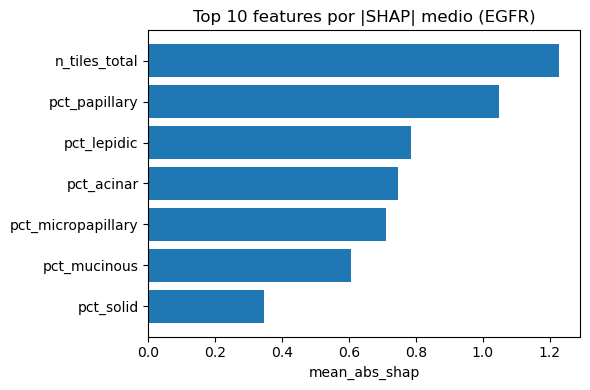

[OK] Guardada figura BAR SHAP para EGFR: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_bar_EGFR.png
[INFO] SHAP values de EGFR leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_EGFR.csv
[INFO] histo_per_case leído de: /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv
[INFO] Generando SHAP summary (beeswarm) para EGFR...


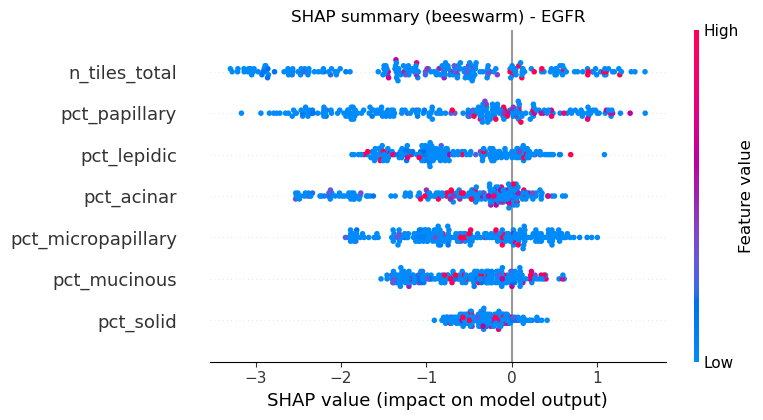

[OK] SHAP beeswarm guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_beeswarm_EGFR.png
[WARN] No se encontró columna EGFR_mut en histo_per_case, eligiendo primer caso del merge
[INFO] Generando SHAP force plot para EGFR, caso TCGA-05-4249, fila idx=0


<Figure size 800x300 with 0 Axes>

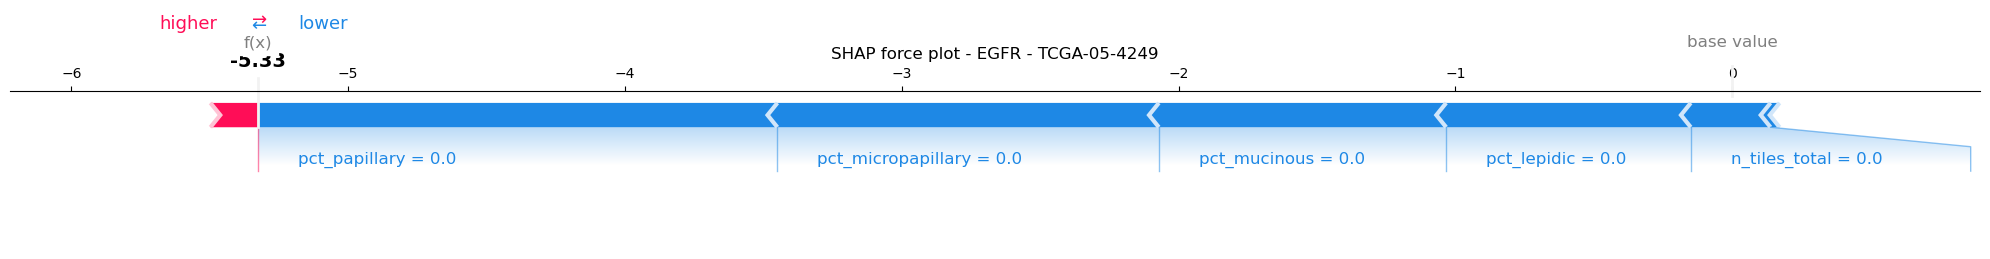

[OK] SHAP force plot guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_force_EGFR_TCGA-05-4249.png


In [29]:
plot_shap_summary_for_gene("EGFR")


[INFO] SHAP summary de TP53 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_TP53.csv


,feature,mean_abs_shap
0,pct_lepidic,0.544600
1,pct_solid,0.482515
2,pct_papillary,0.440628
3,pct_mucinous,0.394605
4,pct_acinar,0.372505


[INFO] Usando columna SHAP 'mean_abs_shap' para TP53


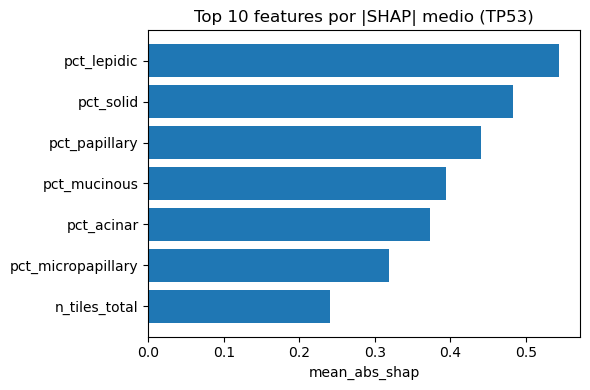

[OK] Guardada figura BAR SHAP para TP53: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_bar_TP53.png
[INFO] SHAP values de TP53 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_TP53.csv
[INFO] histo_per_case leído de: /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv
[INFO] Generando SHAP summary (beeswarm) para TP53...


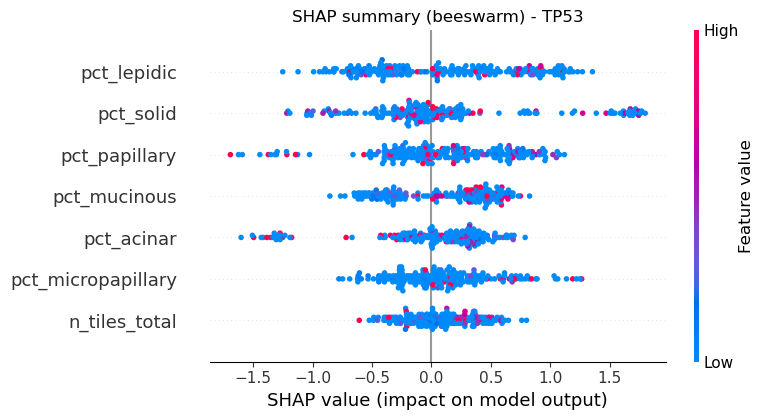

[OK] SHAP beeswarm guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_beeswarm_TP53.png
[WARN] No se encontró columna TP53_mut en histo_per_case, eligiendo primer caso del merge
[INFO] Generando SHAP force plot para TP53, caso TCGA-05-4249, fila idx=0


<Figure size 800x300 with 0 Axes>

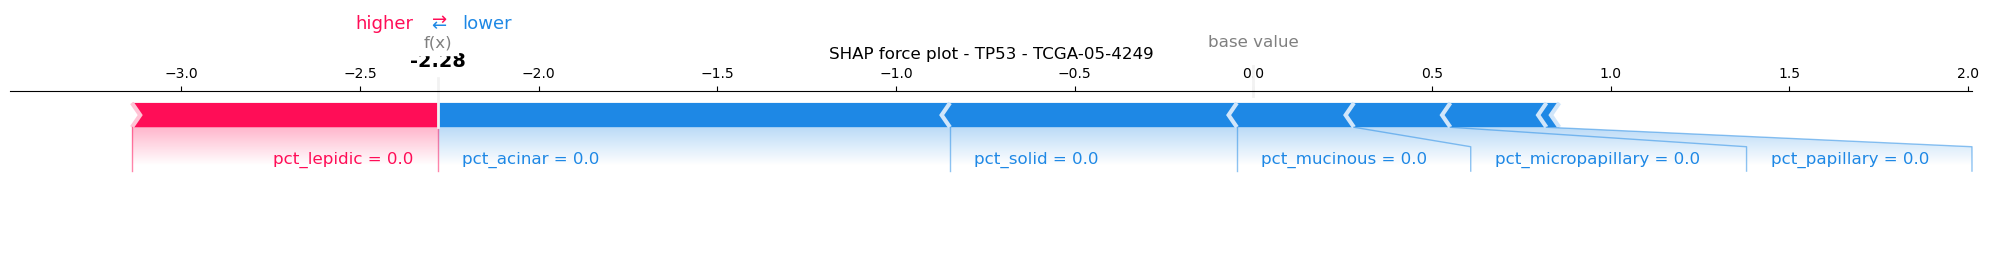

[OK] SHAP force plot guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_force_TP53_TCGA-05-4249.png


In [30]:
plot_shap_summary_for_gene("TP53")


[INFO] SHAP summary de KEAP1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_KEAP1.csv


,feature,mean_abs_shap
0,pct_micropapillary,0.827705
1,pct_solid,0.802956
2,pct_lepidic,0.754411
3,n_tiles_total,0.643707
4,pct_acinar,0.628259


[INFO] Usando columna SHAP 'mean_abs_shap' para KEAP1


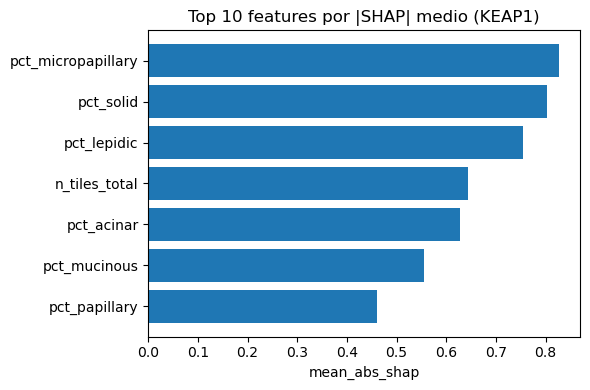

[OK] Guardada figura BAR SHAP para KEAP1: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_bar_KEAP1.png
[INFO] SHAP values de KEAP1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_KEAP1.csv
[INFO] histo_per_case leído de: /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv
[INFO] Generando SHAP summary (beeswarm) para KEAP1...


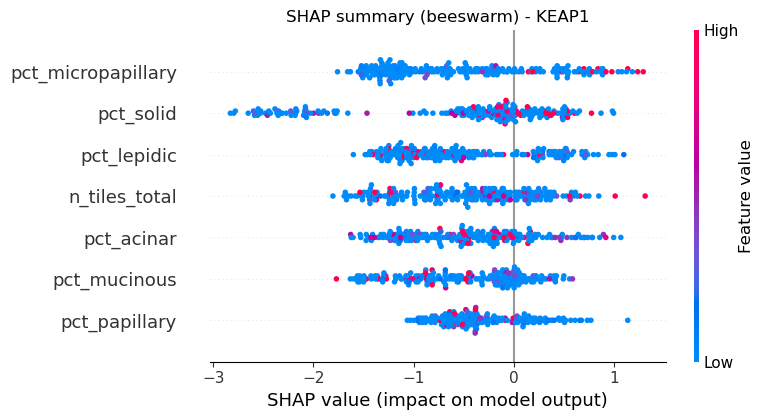

[OK] SHAP beeswarm guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_beeswarm_KEAP1.png
[WARN] No se encontró columna KEAP1_mut en histo_per_case, eligiendo primer caso del merge
[INFO] Generando SHAP force plot para KEAP1, caso TCGA-05-4249, fila idx=0


<Figure size 800x300 with 0 Axes>

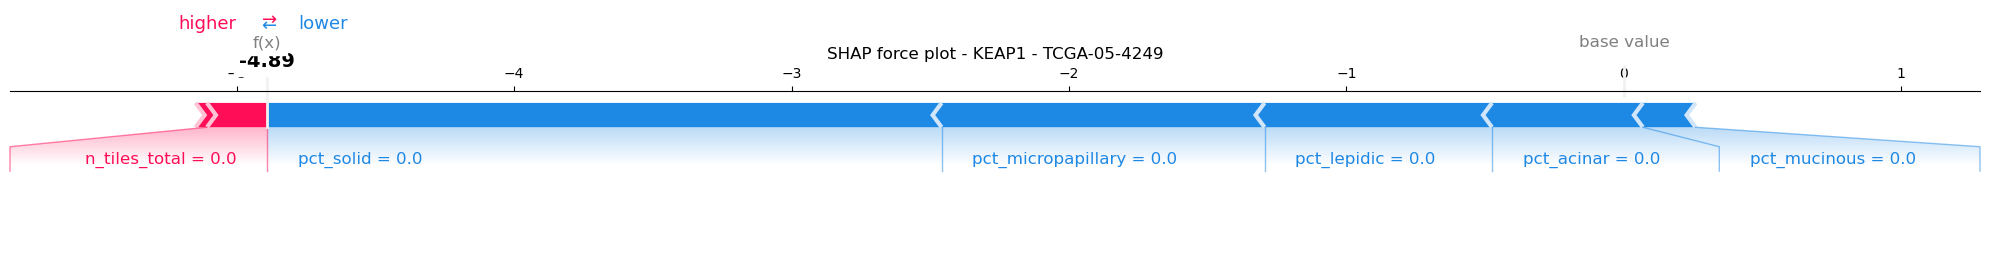

[OK] SHAP force plot guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_force_KEAP1_TCGA-05-4249.png


In [31]:
plot_shap_summary_for_gene("KEAP1")


[INFO] SHAP summary de NF1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_NF1.csv


,feature,mean_abs_shap
0,pct_micropapillary,1.474081
1,pct_lepidic,1.010000
2,pct_mucinous,0.978190
3,n_tiles_total,0.890204
4,pct_solid,0.661763


[INFO] Usando columna SHAP 'mean_abs_shap' para NF1


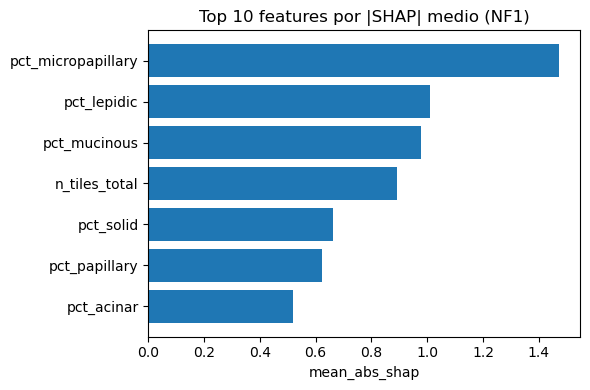

[OK] Guardada figura BAR SHAP para NF1: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_bar_NF1.png
[INFO] SHAP values de NF1 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_NF1.csv
[INFO] histo_per_case leído de: /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv
[INFO] Generando SHAP summary (beeswarm) para NF1...


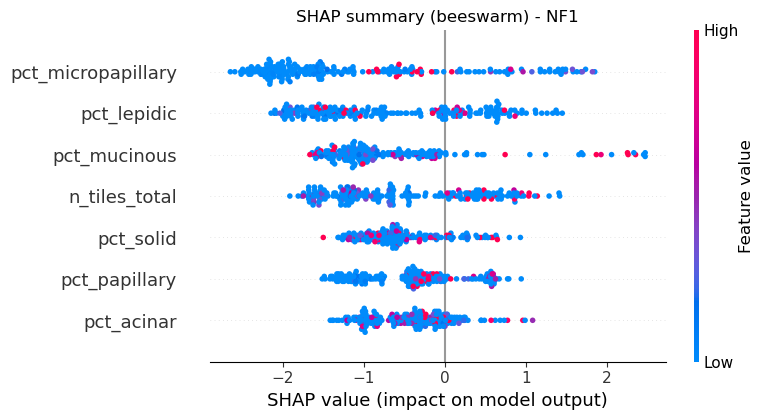

[OK] SHAP beeswarm guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_beeswarm_NF1.png
[WARN] No se encontró columna NF1_mut en histo_per_case, eligiendo primer caso del merge
[INFO] Generando SHAP force plot para NF1, caso TCGA-05-4249, fila idx=0


<Figure size 800x300 with 0 Axes>

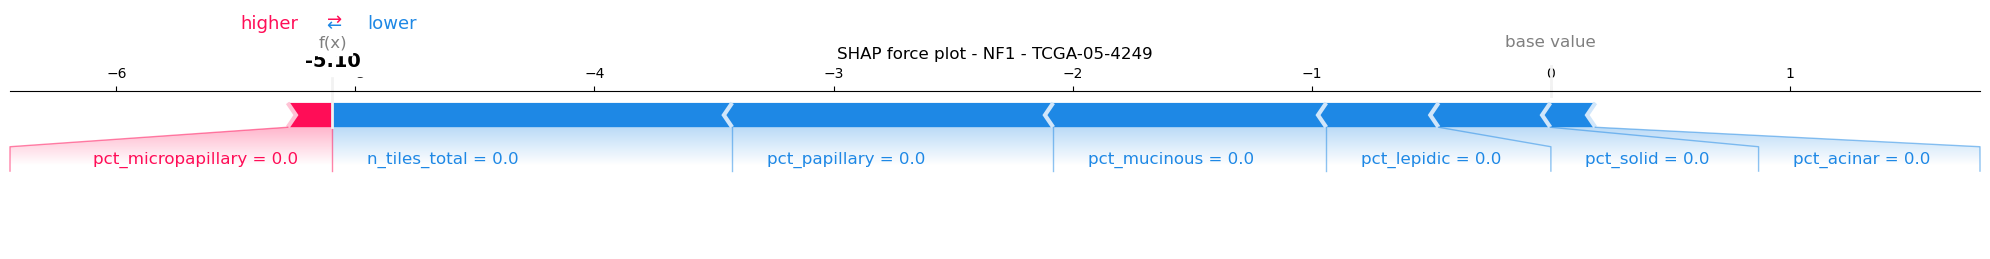

[OK] SHAP force plot guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_force_NF1_TCGA-05-4249.png


In [32]:
plot_shap_summary_for_gene("NF1")


[INFO] SHAP summary de STK11 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_STK11.csv


,feature,mean_abs_shap
0,pct_papillary,1.689100
1,pct_solid,1.450528
2,n_tiles_total,1.278518
3,pct_lepidic,0.996877
4,pct_micropapillary,0.888120


[INFO] Usando columna SHAP 'mean_abs_shap' para STK11


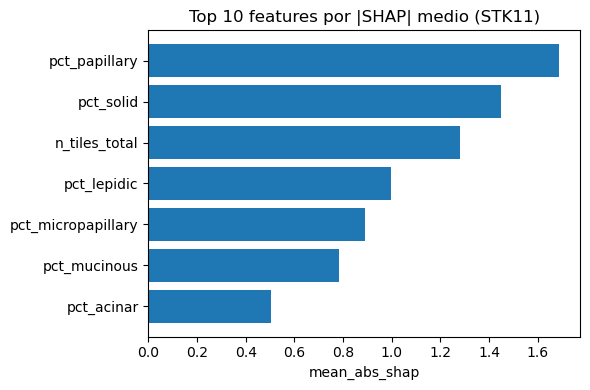

[OK] Guardada figura BAR SHAP para STK11: /home/rapids/notebooks/slima/MAF/xgb_results/shap_summary_bar_STK11.png
[INFO] SHAP values de STK11 leído de: /home/rapids/notebooks/slima/MAF/xgb_results/shap_values_STK11.csv
[INFO] histo_per_case leído de: /home/rapids/notebooks/slima/MAF/xgb_results/histo_per_case.csv
[INFO] Generando SHAP summary (beeswarm) para STK11...


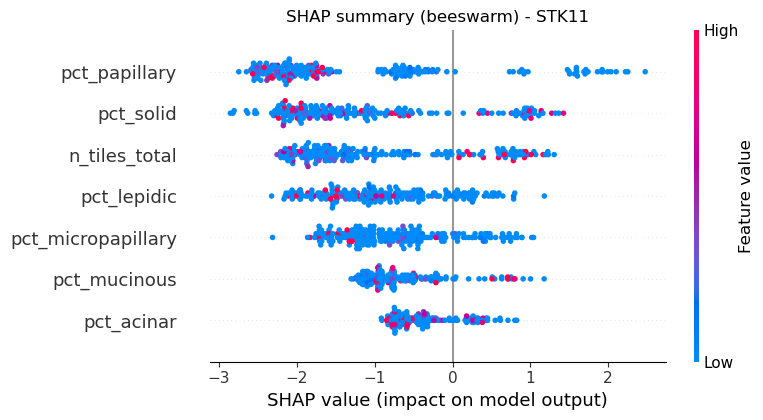

[OK] SHAP beeswarm guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_beeswarm_STK11.png
[WARN] No se encontró columna STK11_mut en histo_per_case, eligiendo primer caso del merge
[INFO] Generando SHAP force plot para STK11, caso TCGA-05-4249, fila idx=0


<Figure size 800x300 with 0 Axes>

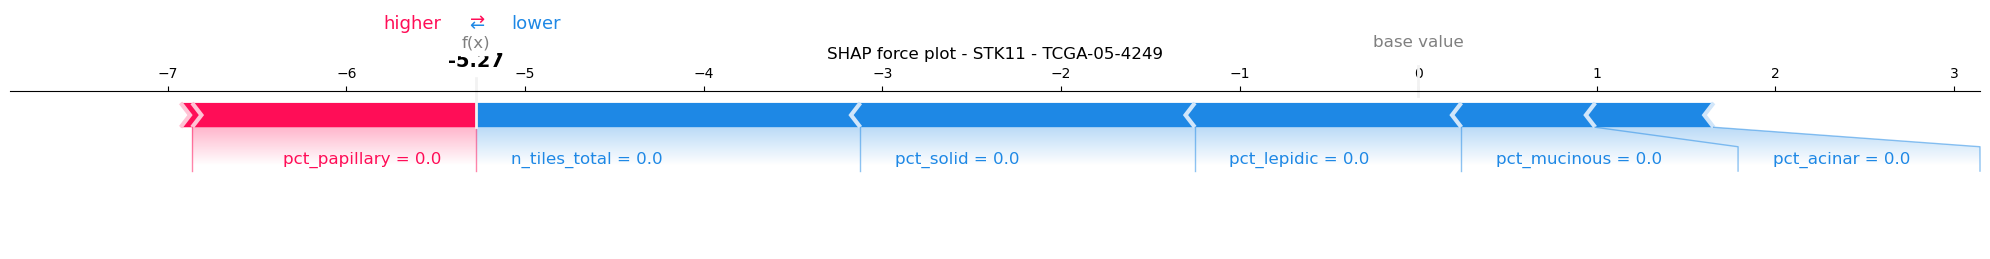

[OK] SHAP force plot guardado en: /home/rapids/notebooks/slima/MAF/xgb_results/shap_force_STK11_TCGA-05-4249.png


In [33]:
plot_shap_summary_for_gene("STK11")
